# Import Required Libraries


In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # Statistical Analysis
from datetime import datetime
# File Handling
import os
from pathlib import Path
# PostgreSQL
import psycopg2
from sqlalchemy import create_engine

# Display all columns
pd.set_option("display.max_columns", None)

# Display up to 100 rows
pd.set_option("display.max_rows", 100)

# Display floating-point numbers with 2 decimal places
pd.options.display.float_format = "{:.2f}".format

# Set Seaborn theme
sns.set_theme(style="whitegrid")

print("=" * 60)
print("✅ All required libraries imported successfully!")
print("=" * 60)

✅ All required libraries imported successfully!


In [180]:
# Display the current working directory

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
E:\Projects\Retail Sales & Customer Analytics Platform\notebooks


In [181]:
# Step 2 : Locate Dataset Files

# Create the path to the raw data folder
data_path = Path("../data/raw")

# Check whether the folder exists
print("Folder Exists :", data_path.exists())

# Display the folder path
print("\nDataset Folder:")
print(data_path.resolve())

Folder Exists : True

Dataset Folder:
E:\Projects\Retail Sales & Customer Analytics Platform\data\raw


In [182]:
# Step 3 : Display CSV Files


# Find all CSV files inside the raw data folder
csv_files = sorted(data_path.glob("*.csv"))

# Display the total number of files
print(f"Total CSV Files Found : {len(csv_files)}\n")

# Display every file name
for index, file in enumerate(csv_files, start=1):
    print(f"{index}. {file.name}")

Total CSV Files Found : 9

1. olist_customers_dataset.csv
2. olist_geolocation_dataset.csv
3. olist_order_items_dataset.csv
4. olist_order_payments_dataset.csv
5. olist_order_reviews_dataset.csv
6. olist_orders_dataset.csv
7. olist_products_dataset.csv
8. olist_sellers_dataset.csv
9. product_category_name_translation.csv


In [183]:
# Step 4 : Dataset Inventory

# Create a dataset inventory table

dataset_inventory = pd.DataFrame({

    "Dataset": [
        "Customers",
        "Geolocation",
        "Order Items",
        "Order Payments",
        "Order Reviews",
        "Orders",
        "Products",
        "Sellers",
        "Category Translation"
    ],

    "CSV File": [
        "olist_customers_dataset.csv",
        "olist_geolocation_dataset.csv",
        "olist_order_items_dataset.csv",
        "olist_order_payments_dataset.csv",
        "olist_order_reviews_dataset.csv",
        "olist_orders_dataset.csv",
        "olist_products_dataset.csv",
        "olist_sellers_dataset.csv",
        "product_category_name_translation.csv"
    ],

    "Business Purpose": [
        "Customer Information",
        "Customer Geographic Location",
        "Products Purchased in Each Order",
        "Payment Details",
        "Customer Reviews",
        "Order Information",
        "Product Information",
        "Seller Information",
        "Category Name Translation"
    ],

    "Primary Key": [
        "customer_id",
        "None",
        "order_id + order_item_id",
        "order_id + payment_sequential",
        "review_id",
        "order_id",
        "product_id",
        "seller_id",
        "product_category_name"
    ]
})

dataset_inventory

,Dataset,CSV File,Business Purpose,Primary Key
0,Customers,olist_customers_dataset.csv,Customer Information,customer_id
1,Geolocation,olist_geolocation_dataset.csv,Customer Geographic Location,None
2,Order Items,olist_order_items_dataset.csv,Products Purchased in Each Order,order_id + order_item_id
3,Order Payments,olist_order_payments_dataset.csv,Payment Details,order_id + payment_sequential
4,Order Reviews,olist_order_reviews_dataset.csv,Customer Reviews,review_id
5,Orders,olist_orders_dataset.csv,Order Information,order_id
6,Products,olist_products_dataset.csv,Product Information,product_id
7,Sellers,olist_sellers_dataset.csv,Seller Information,seller_id
8,Category Translation,product_category_name_translation.csv,Category Name Translation,product_category_name


In [184]:
dataset_inventory.head()

,Dataset,CSV File,Business Purpose,Primary Key
0,Customers,olist_customers_dataset.csv,Customer Information,customer_id
1,Geolocation,olist_geolocation_dataset.csv,Customer Geographic Location,None
2,Order Items,olist_order_items_dataset.csv,Products Purchased in Each Order,order_id + order_item_id
3,Order Payments,olist_order_payments_dataset.csv,Payment Details,order_id + payment_sequential
4,Order Reviews,olist_order_reviews_dataset.csv,Customer Reviews,review_id


In [185]:
dataset_inventory.tail()

,Dataset,CSV File,Business Purpose,Primary Key
4,Order Reviews,olist_order_reviews_dataset.csv,Customer Reviews,review_id
5,Orders,olist_orders_dataset.csv,Order Information,order_id
6,Products,olist_products_dataset.csv,Product Information,product_id
7,Sellers,olist_sellers_dataset.csv,Seller Information,seller_id
8,Category Translation,product_category_name_translation.csv,Category Name Translation,product_category_name


In [186]:
dataset_inventory.sample()

,Dataset,CSV File,Business Purpose,Primary Key
1,Geolocation,olist_geolocation_dataset.csv,Customer Geographic Location,None


In [187]:
dataset_inventory.shape

(9, 4)

In [188]:
dataset_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Dataset           9 non-null      object
 1   CSV File          9 non-null      object
 2   Business Purpose  9 non-null      object
 3   Primary Key       9 non-null      object
dtypes: object(4)
memory usage: 416.0+ bytes


In [189]:
dataset_inventory.describe()

,Dataset,CSV File,Business Purpose,Primary Key
count,9,9,9,9
unique,9,9,9,9
top,Customers,olist_customers_dataset.csv,Customer Information,customer_id
freq,1,1,1,1


In [190]:

# Step 6 : Load Customers Dataset

# Load the Customers dataset

customers_df = pd.read_csv(
    data_path / "olist_customers_dataset.csv"
)

print("✅ Customers dataset loaded successfully!")

✅ Customers dataset loaded successfully!


In [191]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [192]:
customers_df.tail()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP


In [193]:
customers_df.shape

(99441, 5)

In [194]:
customers_df.sample()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
29173,72f4de2d0b788e1cf5e209886736de7c,62a10d90dc65c0c75cc617da952f261a,35900,itabira,MG


In [195]:
customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [196]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [197]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.00
mean,35137.47
std,29797.94
min,1003.00
25%,11347.00
50%,24416.00
75%,58900.00
max,99990.00


In [198]:
customers_df.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [199]:
customers_df.size

497205

In [200]:
# Step 8 : Missing Value Analysis

# Count missing values in each column
missing_values = customers_df.isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(customers_df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

# Display only columns with missing values
missing_summary[missing_summary["Missing Values"] > 0]

# Display results
if missing_summary.empty:
    print("✅ No missing values found in the Customers dataset.")
else:
    display(missing_summary)

,Missing Values,Missing Percentage (%)
customer_id,0,0.00
customer_unique_id,0,0.00
customer_zip_code_prefix,0,0.00
customer_city,0,0.00
customer_state,0,0.00


In [201]:

# Count duplicate rows
duplicate_rows = customers_df.duplicated().sum()

print(f"Total Duplicate Rows : {duplicate_rows}")

Total Duplicate Rows : 0


In [202]:

# Step 10 : Unique Values

print("Unique Customers :", customers_df["customer_id"].nunique())
print("Unique Customer Unique IDs :", customers_df["customer_unique_id"].nunique())
print("Unique Cities :", customers_df["customer_city"].nunique())
print("Unique States :", customers_df["customer_state"].nunique())

Unique Customers : 99441
Unique Customer Unique IDs : 96096
Unique Cities : 4119
Unique States : 27


In [203]:
# Step 12 : Load Orders Dataset

# Load the Orders dataset
orders_df = pd.read_csv(
    data_path / "olist_orders_dataset.csv"
)

print("✅ Orders dataset loaded successfully!")

✅ Orders dataset loaded successfully!


In [204]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [205]:
orders_df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00


In [206]:
orders_df.shape

(99441, 8)

In [207]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [208]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [209]:
orders_df.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [210]:
# Step 13 : Load Orders Dataset

# Load the Orders dataset
orders_df = pd.read_csv(
    data_path / "olist_orders_dataset.csv"
)

print("✅ Orders dataset loaded successfully!")

✅ Orders dataset loaded successfully!


In [211]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [212]:
orders_df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00


In [213]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [214]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [215]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [216]:
orders_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [217]:
orders_df.size

795528

In [218]:
orders_df.sample(5, random_state=42)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
52263,b9a6c5f5df52c7226ac85aee7524c27f,f160aaf480efdfa7268f0fa535f73e76,delivered,2018-06-12 20:07:44,2018-06-12 20:44:26,2018-06-13 13:09:00,2018-06-19 12:44:08,2018-07-17 00:00:00
46645,261e71d2349c713eafa9f3df5972b95d,d6708bbbd2d419475869a84e41f620a1,delivered,2018-01-20 12:15:57,2018-01-20 12:37:13,2018-01-25 21:42:52,2018-01-30 11:32:35,2018-02-15 00:00:00
37546,67b50899f52995848c427e361e10dde3,1b353c00c71689afba44554e43cc5a76,delivered,2018-06-16 21:24:10,2018-06-16 21:36:59,2018-06-21 13:55:00,2018-06-27 13:17:27,2018-07-16 00:00:00
94756,32733fc014b67ef70fa6039dd8c6ba82,ad66699beab381d0747605f108cc02b4,delivered,2017-08-30 21:12:28,2017-08-31 02:50:24,2017-09-12 20:16:46,2017-09-25 17:53:23,2017-09-22 00:00:00
14771,39a70e9e9b729b11dee34ac12478597f,20c678bfce3c8252288f70dd2bee5e51,delivered,2017-08-10 21:26:25,2017-08-10 21:44:13,2017-08-11 19:11:16,2017-08-22 16:45:00,2017-09-12 00:00:00


In [219]:
# Display the number of rows and columns

print(f"Rows    : {orders_df.shape[0]:,}")
print(f"Columns : {orders_df.shape[1]}")

Rows    : 99,441
Columns : 8


In [220]:
# Display all column names

orders_df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [221]:
# Missing values count
missing_values=orders_df.isnull().sum()

In [222]:
#missing percentages

missing_percentage= (missing_values /len(orders_df))* 100

In [223]:
# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})


In [224]:
# Show only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

if missing_summary.empty:
    print("✅ No missing values found in the Orders dataset.")
else:
    display(missing_summary)

,Missing Values,Missing Percentage (%)
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98


In [225]:
# Count duplicate rows

duplicate_rows = orders_df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicate_rows}")

Total Duplicate Rows: 0


In [226]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [227]:
# Count unique values in key columns

print(f"Unique Orders     : {orders_df['order_id'].nunique():,}")
print(f"Unique Customers  : {orders_df['customer_id'].nunique():,}")
print(f"Order Status Types: {orders_df['order_status'].nunique()}")

Unique Orders     : 99,441
Unique Customers  : 99,441
Order Status Types: 8


In [228]:
orders_df.shape

(99441, 8)

In [229]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [230]:
# ==========================================================
# Missing Value Analysis
# ==========================================================

missing_values = orders_df.isnull().sum()

missing_percentage = (missing_values / len(orders_df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

display(missing_summary)

,Missing Values,Missing Percentage (%)
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98


In [231]:
duplicate_rows = orders_df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


In [232]:
print("Unique Orders           :", orders_df["order_id"].nunique())
print("Unique Customers        :", orders_df["customer_id"].nunique())
print("Unique Order Statuses   :", orders_df["order_status"].nunique())

print("\nOrder Status Distribution:")
print(orders_df["order_status"].value_counts())

Unique Orders           : 99441
Unique Customers        : 99441
Unique Order Statuses   : 8

Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [233]:
# Step 16 : Load Order Items Dataset

# Load the Order Items dataset
order_items_df = pd.read_csv(
    data_path / "olist_order_items_dataset.csv"
)

print("✅ Order Items dataset loaded successfully!")

✅ Order Items dataset loaded successfully!


In [234]:
# Display first five rows
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [235]:
# Display dataset shape

print(f"Rows    : {order_items_df.shape[0]:,}")
print(f"Columns : {order_items_df.shape[1]}")

Rows    : 112,650
Columns : 7


In [236]:
# Display column names

order_items_df.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [237]:
# Dataset information

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [238]:
# Summary statistics

order_items_df.describe()

,order_item_id,price,freight_value
count,112650.00,112650.00,112650.00
mean,1.20,120.65,19.99
std,0.71,183.63,15.81
min,1.00,0.85,0.00
25%,1.00,39.90,13.08
50%,1.00,74.99,16.26
75%,1.00,134.90,21.15
max,21.00,6735.00,409.68


In [239]:
# ==========================================================
# Missing Value Analysis
# ==========================================================

missing_values = order_items_df.isnull().sum()

missing_percentage = (
    missing_values / len(order_items_df)
) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
]

if missing_summary.empty:
    print("✅ No missing values found in the Order Items dataset.")
else:
    display(missing_summary)

✅ No missing values found in the Order Items dataset.


In [240]:
# Duplicate rows

duplicate_rows = order_items_df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows}")

Duplicate Rows : 0


In [241]:
# Unique value analysis

print(f"Unique Orders   : {order_items_df['order_id'].nunique():,}")
print(f"Unique Products : {order_items_df['product_id'].nunique():,}")
print(f"Unique Sellers  : {order_items_df['seller_id'].nunique():,}")

Unique Orders   : 98,666
Unique Products : 32,951
Unique Sellers  : 3,095


In [242]:
# ==========================================================
# Utility Function 1 : Dataset Overview
# ==========================================================

def dataset_overview(df, dataset_name):
    """
    Displays a quick overview of the dataset.

    Parameters
    ----------
    df : pandas DataFrame
        Dataset to analyze

    dataset_name : str
        Name of the dataset
    """

    print("=" * 70)
    print(f"📊 DATASET : {dataset_name.upper()}")
    print("=" * 70)

    print(f"\nRows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]}")

    print("\nColumn Names\n")
    print(df.columns.tolist())

    print("\nData Types\n")
    display(df.dtypes)

    print("\nFirst Five Records\n")
    display(df.head())

In [243]:
dataset_overview(customers_df, "Customers")

📊 DATASET : CUSTOMERS

Rows    : 99,441
Columns : 5

Column Names

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data Types



customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object


First Five Records



,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [244]:
# ==========================================================
# Utility Function 2 : Data Quality Report
# ==========================================================

def data_quality_report(df):
    """
    Generates a data quality report.

    Parameters
    ----------
    df : pandas DataFrame
    """

    missing_values = df.isnull().sum()

    missing_percentage = (
        missing_values / len(df)
    ) * 100

    quality_report = pd.DataFrame({

        "Data Type": df.dtypes,

        "Missing Values": missing_values,

        "Missing (%)": missing_percentage,

        "Unique Values": df.nunique()

    })

    return quality_report

In [245]:
data_quality_report(customers_df)

,Data Type,Missing Values,Missing (%),Unique Values
customer_id,object,0,0.00,99441
customer_unique_id,object,0,0.00,96096
customer_zip_code_prefix,int64,0,0.00,14994
customer_city,object,0,0.00,4119
customer_state,object,0,0.00,27


In [246]:
# ==========================================================
# Utility Function 3 : Duplicate Check
# ==========================================================

def check_duplicates(df):

    duplicates = df.duplicated().sum()

    print("=" * 50)

    print(f"Duplicate Rows : {duplicates:,}")

    print("=" * 50)

In [247]:
# ==========================================================
# Utility Function 4 : Missing Values
# ==========================================================

def missing_value_summary(df):

    missing = df.isnull().sum()

    percentage = (
        missing / len(df)
    ) * 100

    report = pd.DataFrame({

        "Missing Values": missing,

        "Missing Percentage (%)": percentage

    })

    report = report[
        report["Missing Values"] > 0
    ]

    if report.empty:

        print("✅ No Missing Values Found")

    else:

        display(report)

In [248]:
# ==========================================================
# Utility Function 5 : Memory Usage
# ==========================================================

def memory_usage(df):

    memory = df.memory_usage(
        deep=True
    ).sum() / 1024**2

    print(f"Memory Usage : {memory:.2f} MB")

In [249]:
# ==========================================================
# Utility Function 6 : Complete Dataset Summary
# ==========================================================

def analyze_dataset(df, dataset_name):

    print("\n")
    print("=" * 80)
    print(dataset_name.upper())
    print("=" * 80)

    print(f"\nRows : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]}")

    print("\nFirst Five Rows")
    display(df.head())

    print("\nDataset Information")
    df.info()

    print("\nMissing Values")
    missing_value_summary(df)

    print("\nDuplicate Rows")
    check_duplicates(df)

    print("\nMemory Usage")
    memory_usage(df)

In [250]:
# ==========================================================
# Step 17 : Load Products Dataset
# ==========================================================

# Load the Products dataset
products_df = pd.read_csv(
    data_path / "olist_products_dataset.csv"
)

print("✅ Products dataset loaded successfully!")

✅ Products dataset loaded successfully!


In [251]:
analyze_dataset(products_df, "Products")



PRODUCTS

Rows : 32,951
Columns : 9

First Five Rows


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

Missing Values


,Missing Values,Missing Percentage (%)
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01



Duplicate Rows
Duplicate Rows : 0

Memory Usage
Memory Usage : 6.79 MB


In [252]:
# Display descriptive statistics for numeric columns
products_df.describe()


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.00,32341.00,32341.00,32949.00,32949.00,32949.00,32949.00
mean,48.48,771.50,2.19,2276.47,30.82,16.94,23.20
std,10.25,635.12,1.74,4282.04,16.91,13.64,12.08
min,5.00,4.00,1.00,0.00,7.00,2.00,6.00
25%,42.00,339.00,1.00,300.00,18.00,8.00,15.00
50%,51.00,595.00,1.00,700.00,25.00,13.00,20.00
75%,57.00,972.00,3.00,1900.00,38.00,21.00,30.00
max,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00


In [253]:
print(f"Unique Products          : {products_df['product_id'].nunique():,}")
print(f"Unique Product Categories: {products_df['product_category_name'].nunique()}")

Unique Products          : 32,951
Unique Product Categories: 73


In [254]:
# ==========================================================
# Step 17 : Load Products Dataset
# ==========================================================

# Load the Products dataset
products_df = pd.read_csv(
    data_path / "olist_products_dataset.csv"
)

print("✅ Products dataset loaded successfully!")

✅ Products dataset loaded successfully!


In [255]:
# Analyze the Products dataset
analyze_dataset(products_df, "Products")



PRODUCTS

Rows : 32,951
Columns : 9

First Five Rows


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

Missing Values


,Missing Values,Missing Percentage (%)
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01



Duplicate Rows
Duplicate Rows : 0

Memory Usage
Memory Usage : 6.79 MB


In [256]:
# Display summary statistics
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.00,32341.00,32341.00,32949.00,32949.00,32949.00,32949.00
mean,48.48,771.50,2.19,2276.47,30.82,16.94,23.20
std,10.25,635.12,1.74,4282.04,16.91,13.64,12.08
min,5.00,4.00,1.00,0.00,7.00,2.00,6.00
25%,42.00,339.00,1.00,300.00,18.00,8.00,15.00
50%,51.00,595.00,1.00,700.00,25.00,13.00,20.00
75%,57.00,972.00,3.00,1900.00,38.00,21.00,30.00
max,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00


In [257]:
# Count unique values in important columns

print(f"Unique Products            : {products_df['product_id'].nunique():,}")
print(f"Unique Categories          : {products_df['product_category_name'].nunique()}")

Unique Products            : 32,951
Unique Categories          : 73


In [258]:
# Check duplicate Product IDs

duplicate_product_ids = products_df['product_id'].duplicated().sum()

print(f"Duplicate Product IDs : {duplicate_product_ids}")

Duplicate Product IDs : 0


In [259]:
# Display missing values

missing_value_summary(products_df)

,Missing Values,Missing Percentage (%)
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


In [260]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [261]:
# ==========================================================
# Step 18 : Load Sellers Dataset
# ==========================================================

# Load the Sellers dataset
sellers_df = pd.read_csv(
    data_path / "olist_sellers_dataset.csv"
)

print("✅ Sellers dataset loaded successfully!")

✅ Sellers dataset loaded successfully!


In [262]:
# Analyze the Sellers dataset
analyze_dataset(sellers_df, "Sellers")

# Summary statistics
sellers_df.describe()

print(f"Unique Sellers : {sellers_df['seller_id'].nunique():,}")
print(f"Unique Cities  : {sellers_df['seller_city'].nunique()}")
print(f"Unique States  : {sellers_df['seller_state'].nunique()}")

# Check duplicate Seller IDs
duplicate_seller_ids = sellers_df["seller_id"].duplicated().sum()

print(f"Duplicate Seller IDs : {duplicate_seller_ids}")

# Missing values
missing_value_summary(sellers_df)

sellers_df.info()



SELLERS

Rows : 3,095
Columns : 4

First Five Rows


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

Missing Values
✅ No Missing Values Found

Duplicate Rows
Duplicate Rows : 0

Memory Usage
Memory Usage : 0.66 MB
Unique Sellers : 3,095
Unique Cities  : 611
Unique States  : 23
Duplicate Seller IDs : 0
✅ No Missing Values Found
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_cod

In [263]:
# ==========================================================
# Step 19 : Load Order Payments Dataset
# ==========================================================

payments_df = pd.read_csv(
    data_path / "olist_order_payments_dataset.csv"
)

print("✅ Payments dataset loaded successfully!")

analyze_dataset(payments_df, "Order Payments")

payments_df.describe()

print(f"Unique Orders          : {payments_df['order_id'].nunique():,}")
print(f"Payment Types          : {payments_df['payment_type'].nunique()}")
print(f"Maximum Installments   : {payments_df['payment_installments'].max()}")

duplicate_payment_rows = payments_df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_payment_rows}")

missing_value_summary(payments_df)

✅ Payments dataset loaded successfully!


ORDER PAYMENTS

Rows : 103,886
Columns : 5

First Five Rows


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

Missing Values
✅ No Missing Values Found

Duplicate Rows
Duplicate Rows : 0

Memory Usage
Memory Usage : 17.81 MB
Unique Orders          : 99,440
Payment Types          : 5
Maximum Installments   : 24
Duplicate Rows : 0
✅ No Missing Values Found


In [264]:
reviews_df = pd.read_csv(
    data_path / "olist_order_reviews_dataset.csv"
)

print("✅ Reviews dataset loaded successfully!")

analyze_dataset(reviews_df, "Order Reviews")

reviews_df.describe(include="all")

print(f"Unique Reviews : {reviews_df['review_id'].nunique():,}")
print(f"Unique Orders  : {reviews_df['order_id'].nunique():,}")

duplicate_reviews = reviews_df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_reviews}")

missing_value_summary(reviews_df)

✅ Reviews dataset loaded successfully!


ORDER REVIEWS

Rows : 99,224
Columns : 7

First Five Rows


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

Missing Values


,Missing Values,Missing Percentage (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70



Duplicate Rows
Duplicate Rows : 0

Memory Usage
Memory Usage : 42.75 MB
Unique Reviews : 98,410
Unique Orders  : 98,673
Duplicate Rows : 0


,Missing Values,Missing Percentage (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70


In [265]:
geolocation_df = pd.read_csv(
    data_path / "olist_geolocation_dataset.csv"
)

print("✅ Geolocation dataset loaded successfully!")

analyze_dataset(geolocation_df, "Geolocation")

geolocation_df.describe()

print(f"Unique ZIP Prefixes : {geolocation_df['geolocation_zip_code_prefix'].nunique():,}")
print(f"Unique Cities       : {geolocation_df['geolocation_city'].nunique()}")
print(f"Unique States       : {geolocation_df['geolocation_state'].nunique()}")

duplicate_geo = geolocation_df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_geo}")

missing_value_summary(geolocation_df)

✅ Geolocation dataset loaded successfully!


GEOLOCATION

Rows : 1,000,163
Columns : 5

First Five Rows


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
3,1041,-23.54,-46.64,sao paulo,SP
4,1035,-23.54,-46.64,sao paulo,SP



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB

Missing Values
✅ No Missing Values Found

Duplicate Rows
Duplicate Rows : 261,831

Memory Usage
Memory Usage : 146.09 MB
Unique ZIP Prefixes : 19,015
Unique Cities       : 8011
Unique States       : 27
Duplicate Rows : 261831
✅ No Missing Values Found


In [266]:
category_translation_df = pd.read_csv(
    data_path / "product_category_name_translation.csv"
)

print("✅ Category Translation dataset loaded successfully!")

analyze_dataset(category_translation_df, "Category Translation")

print(f"Unique Categories : {category_translation_df['product_category_name'].nunique()}")

duplicate_categories = category_translation_df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_categories}")

missing_value_summary(category_translation_df)



✅ Category Translation dataset loaded successfully!


CATEGORY TRANSLATION

Rows : 71
Columns : 2

First Five Rows


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB

Missing Values
✅ No Missing Values Found

Duplicate Rows
Duplicate Rows : 0

Memory Usage
Memory Usage : 0.01 MB
Unique Categories : 71
Duplicate Rows : 0
✅ No Missing Values Found


In [267]:
# ==========================================================
# Step 23 : Create Working Copies
# ==========================================================

customers_clean = customers_df.copy()
orders_clean = orders_df.copy()
order_items_clean = order_items_df.copy()
products_clean = products_df.copy()
sellers_clean = sellers_df.copy()
payments_clean = payments_df.copy()
reviews_clean = reviews_df.copy()
geolocation_clean = geolocation_df.copy()
category_translation_clean = category_translation_df.copy()

print("✅ Working copies created successfully!")

✅ Working copies created successfully!


In [268]:
# ==========================================================
# Step 24 : Data Cleaning Log
# ==========================================================

cleaning_log = pd.DataFrame(columns=[
    "Dataset",
    "Issue",
    "Action Taken",
    "Reason"
])

cleaning_log

,Dataset,Issue,Action Taken,Reason


In [269]:
# Display data types for the Orders dataset

orders_clean.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [270]:
# ==========================================================
# Step 26 : Convert Date Columns
# ==========================================================

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders_clean[column] = pd.to_datetime(
        orders_clean[column],
        errors="coerce"
    )

print("✅ Date columns converted successfully!")

✅ Date columns converted successfully!


In [271]:
# Verify updated data types

orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [272]:
# ==========================================================
# Step 27 : Investigate Duplicate Records
# ==========================================================

# Count duplicate rows

duplicate_count = geolocation_clean.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count:,}")

Duplicate Rows : 261,831


In [273]:
# Display duplicate records

duplicate_rows = geolocation_clean[
    geolocation_clean.duplicated(keep=False)
]

duplicate_rows.head(20)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
6,1047,-23.55,-46.64,sao paulo,SP
7,1013,-23.55,-46.63,sao paulo,SP
8,1029,-23.54,-46.63,sao paulo,SP
9,1011,-23.55,-46.64,sao paulo,SP
10,1013,-23.55,-46.63,sao paulo,SP
13,1012,-23.55,-46.63,sao paulo,SP
15,1046,-23.55,-46.64,sao paulo,SP


In [274]:
duplicate_percentage = (
    duplicate_count /
    len(geolocation_clean)
) * 100

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")

Duplicate Percentage : 26.18%


In [275]:
# Display missing values
orders_clean.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [276]:
orders_missing_delivery = orders_clean[
    orders_clean["order_delivered_customer_date"].isna()
]

print(f"Orders with Missing Delivery Date: {len(orders_missing_delivery):,}")

orders_missing_delivery.head()

Orders with Missing Delivery Date: 2,965


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07


In [277]:
# Check the order status of orders with missing delivery dates

orders_missing_delivery["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [278]:
# Percentage of missing delivery dates

missing_delivery_percentage = (
    len(orders_missing_delivery) / len(orders_clean)
) * 100

print(f"Missing Delivery Dates : {missing_delivery_percentage:.2f}%")

Missing Delivery Dates : 2.98%


In [279]:
# ==========================================================
# Step 2.6.1 : Order Status Distribution
# ==========================================================

# Count orders by status
order_status_counts = (
    orders_clean["order_status"]
    .value_counts()
    .sort_values(ascending=False)
)

print(order_status_counts)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


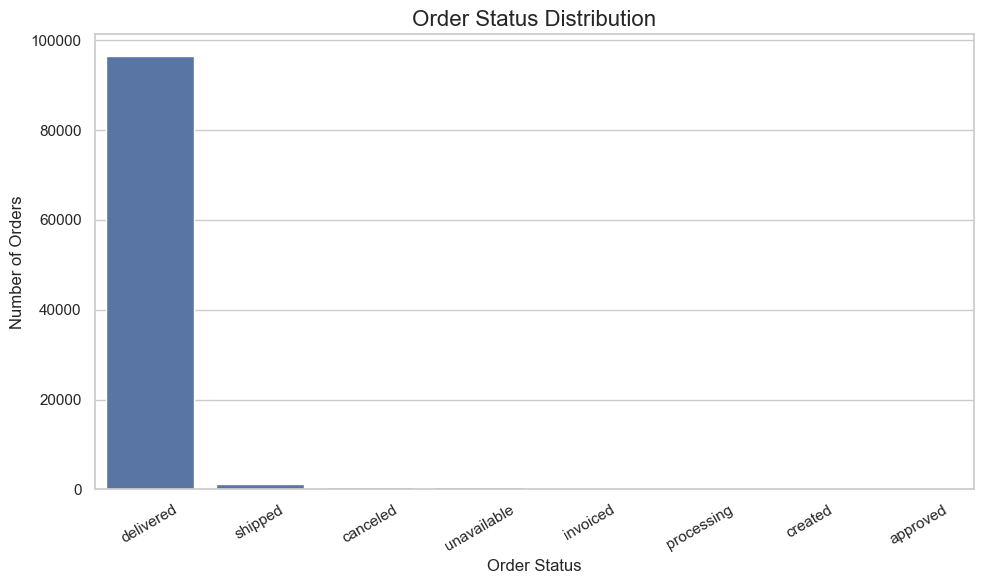

In [280]:
# ==========================================================
# Step 2.6.2 : Visualize Order Status
# ==========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=orders_clean,
    x="order_status",
    order=orders_clean["order_status"].value_counts().index
)

plt.title("Order Status Distribution", fontsize=16)

plt.xlabel("Order Status")

plt.ylabel("Number of Orders")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [281]:
# ==========================================================
# Step 2.6.3 : Create Year-Month Column
# ==========================================================

orders_clean["order_year_month"] = (
    orders_clean["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [282]:
# Monthly order count

monthly_orders = (
    orders_clean
    .groupby("order_year_month")
    .size()
    .reset_index(name="Total Orders")
)

monthly_orders.head()

,order_year_month,Total Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


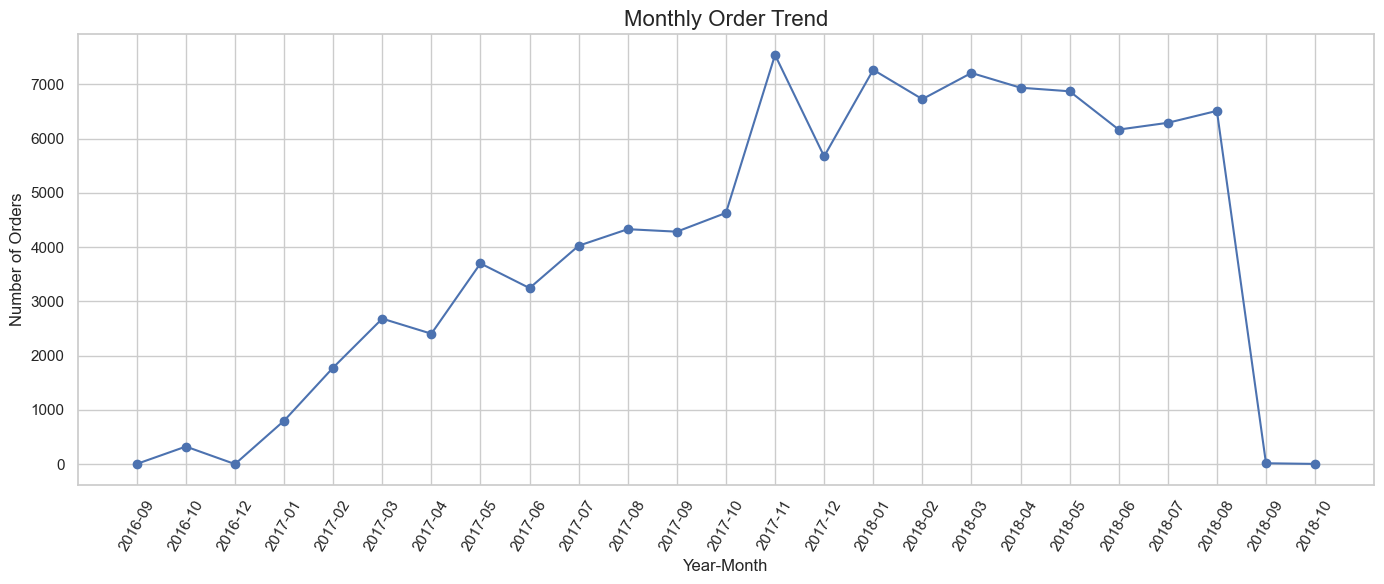

In [283]:
# ==========================================================
# Step 2.6.4 : Monthly Order Trend
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["order_year_month"],
    monthly_orders["Total Orders"],
    marker="o"
)

plt.title("Monthly Order Trend", fontsize=16)

plt.xlabel("Year-Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=60)

plt.tight_layout()

plt.show()

## Business Insight

- The chart shows how customer order volume changes over time.
- Peaks indicate periods of high customer demand.
- Declines may reflect seasonal trends or operational factors.
- Understanding these trends helps businesses plan inventory, staffing, and marketing campaigns.

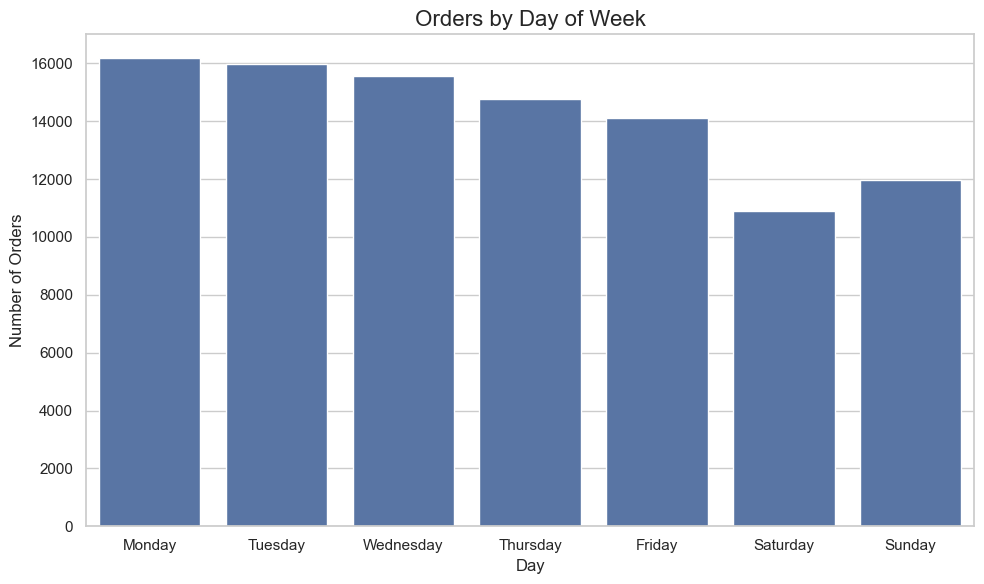

In [284]:
# ==========================================================
# Step 2.6.5 : Day of Week Analysis
# ==========================================================

orders_clean["order_day"] = (
    orders_clean["order_purchase_timestamp"]
    .dt.day_name()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10,6))

sns.countplot(
    data=orders_clean,
    x="order_day",
    order=day_order
)

plt.title("Orders by Day of Week", fontsize=16)

plt.xlabel("Day")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

## Business Insight

- The visualization highlights customer purchasing behavior throughout the week.
- Businesses can use this information to optimize staffing, inventory allocation, and promotional campaigns.

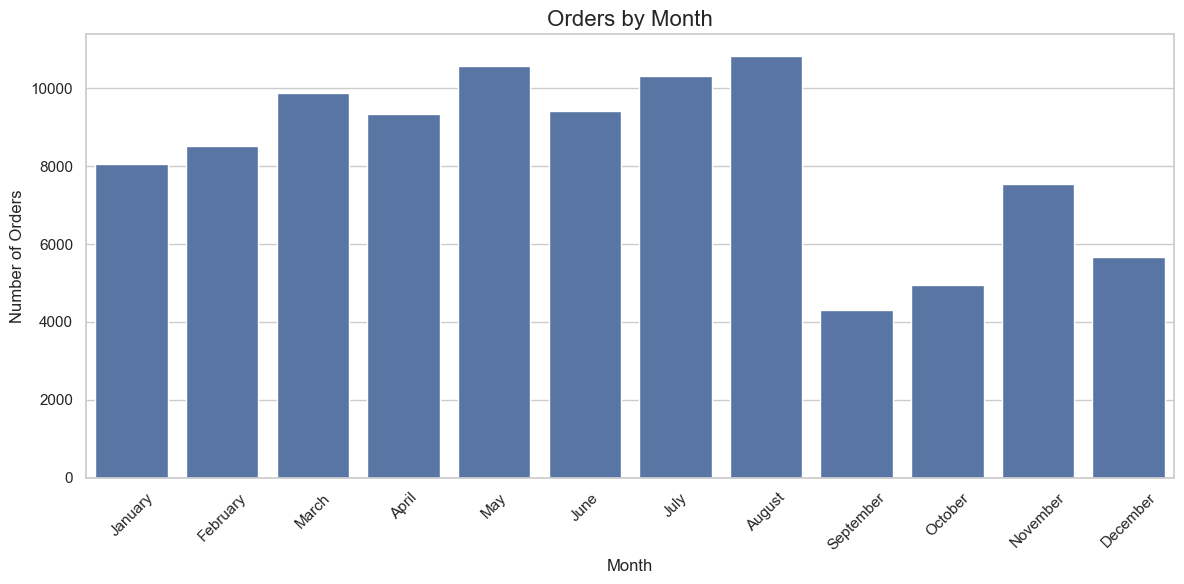

In [285]:
# ==========================================================
# Step 2.6.6 : Orders by Month
# ==========================================================

orders_clean["order_month"] = (
    orders_clean["order_purchase_timestamp"]
    .dt.month_name()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plt.figure(figsize=(12,6))

sns.countplot(
    data=orders_clean,
    x="order_month",
    order=month_order
)

plt.title("Orders by Month", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Create Delivery Time Feature

The delivery time measures the number of days between the customer's purchase and the successful delivery of the order.

This metric is one of the most important KPIs in e-commerce because it directly impacts customer satisfaction.

In [286]:
# ==========================================================
# Step 2.7.1 : Delivery Time (Days)
# ==========================================================

orders_clean["delivery_time_days"] = (
    orders_clean["order_delivered_customer_date"] -
    orders_clean["order_purchase_timestamp"]
).dt.days

orders_clean[[
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "delivery_time_days"
]].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.00
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.00
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.00
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.00
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.00


In [287]:
# ==========================================================
# Step 2.7.2 : Approval Time (Hours)
# ==========================================================

orders_clean["approval_time_hours"] = (
    orders_clean["order_approved_at"] -
    orders_clean["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders_clean[[
    "order_purchase_timestamp",
    "order_approved_at",
    "approval_time_hours"
]].head()

,order_purchase_timestamp,order_approved_at,approval_time_hours
0,2017-10-02 10:56:33,2017-10-02 11:07:15,0.18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,30.71
2,2018-08-08 08:38:49,2018-08-08 08:55:23,0.28
3,2017-11-18 19:28:06,2017-11-18 19:45:59,0.30
4,2018-02-13 21:18:39,2018-02-13 22:20:29,1.03


In [288]:
# ==========================================================
# Step 2.7.3 : Delivery Delay
# ==========================================================

orders_clean["delivery_delay_days"] = (
    orders_clean["order_delivered_customer_date"] -
    orders_clean["order_estimated_delivery_date"]
).dt.days

orders_clean[[
    "order_estimated_delivery_date",
    "order_delivered_customer_date",
    "delivery_delay_days"
]].head()

,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days
0,2017-10-18,2017-10-10 21:25:13,-8.00
1,2018-08-13,2018-08-07 15:27:45,-6.00
2,2018-09-04,2018-08-17 18:06:29,-18.00
3,2017-12-15,2017-12-02 00:28:42,-13.00
4,2018-02-26,2018-02-16 18:17:02,-10.00


Interpretation
Negative → Delivered early
Zero → Delivered on time
Positive → Delivered late

## Feature 4: Estimated vs Actual Delivery

In [289]:
# ==========================================================
# Step 2.7.4 : Estimated vs Actual Delivery
# ==========================================================

orders_clean["estimated_vs_actual_delivery"] = (
    orders_clean["order_estimated_delivery_date"] -
    orders_clean["order_delivered_customer_date"]
).dt.days

orders_clean[[
    "estimated_vs_actual_delivery"
]].head()

,estimated_vs_actual_delivery
0,7.00
1,5.00
2,17.00
3,12.00
4,9.00


## Interpretation
Positive = Delivered before estimated date
Zero = Delivered exactly on time
Negative = Delivered after estimated date

In [290]:
# ==========================================================
# Step 2.7.5 : Order Year
# ==========================================================

orders_clean["order_year"] = (
    orders_clean["order_purchase_timestamp"]
    .dt.year
)

orders_clean["order_year"].value_counts().sort_index()

order_year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64

In [291]:
# ==========================================================
# Step 2.7.6 : Order Quarter
# ==========================================================

orders_clean["order_quarter"] = (
    orders_clean["order_purchase_timestamp"]
    .dt.quarter
)

orders_clean["order_quarter"].value_counts().sort_index()

order_quarter
1    26470
2    29328
3    25466
4    18177
Name: count, dtype: int64

In [292]:
# ==========================================================
# Step 2.7.7 : Is Delayed?
# ==========================================================

orders_clean["is_delayed"] = orders_clean[
    "delivery_delay_days"
].apply(
    lambda x: "Yes"
    if pd.notna(x) and x > 0
    else "No"
)

orders_clean["is_delayed"].value_counts()

is_delayed
No     92906
Yes     6535
Name: count, dtype: int64

In [293]:
# ==========================================================
# Step 2.7.8 : Delivery Status
# ==========================================================

def delivery_status(delay):
    if pd.isna(delay):
        return "Not Delivered"
    elif delay < 0:
        return "Early"
    elif delay == 0:
        return "On Time"
    else:
        return "Late"

orders_clean["delivery_status"] = (
    orders_clean["delivery_delay_days"]
    .apply(delivery_status)
)

orders_clean["delivery_status"].value_counts()

delivery_status
Early            88649
Late              6535
Not Delivered     2965
On Time           1292
Name: count, dtype: int64

In [294]:
# Display the newly created features

orders_clean[[
    "delivery_time_days",
    "approval_time_hours",
    "delivery_delay_days",
    "estimated_vs_actual_delivery",
    "order_year",
    "order_quarter",
    "is_delayed",
    "delivery_status"
]].head()

,delivery_time_days,approval_time_hours,delivery_delay_days,estimated_vs_actual_delivery,order_year,order_quarter,is_delayed,delivery_status
0,8.00,0.18,-8.00,7.00,2017,4,No,Early
1,13.00,30.71,-6.00,5.00,2018,3,No,Early
2,9.00,0.28,-18.00,17.00,2018,3,No,Early
3,13.00,0.30,-13.00,12.00,2017,4,No,Early
4,2.00,1.03,-10.00,9.00,2018,1,No,Early


## KPI 1 – Average Delivery Time

In [295]:
# ==========================================================
# Step 2.8.1 : Average Delivery Time
# ==========================================================

average_delivery_time = orders_clean["delivery_time_days"].mean()

print(f"Average Delivery Time: {average_delivery_time:.2f} days")

Average Delivery Time: 12.09 days


## KPI 2 – Average Order Approval Time

In [296]:
# ==========================================================
# Step 2.8.2 : Average Approval Time
# ==========================================================

average_approval_time = orders_clean["approval_time_hours"].mean()

print(f"Average Approval Time: {average_approval_time:.2f} hours")

Average Approval Time: 10.42 hours


## KPI 3 – Delivery Status Distribution

In [297]:
# ==========================================================
# Step 2.8.3 : Delivery Status Distribution
# ==========================================================

delivery_status_counts = (
    orders_clean["delivery_status"]
    .value_counts()
)

print(delivery_status_counts)

delivery_status
Early            88649
Late              6535
Not Delivered     2965
On Time           1292
Name: count, dtype: int64


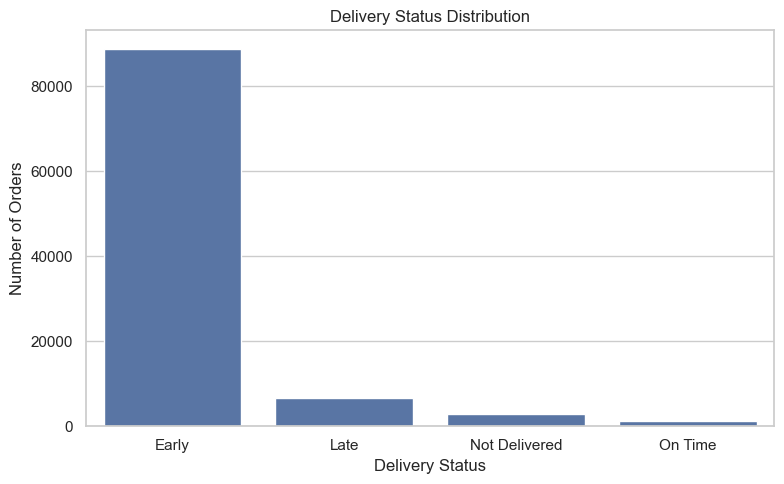

In [298]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders_clean,
    x="delivery_status",
    order=orders_clean["delivery_status"].value_counts().index
)

plt.title("Delivery Status Distribution")

plt.xlabel("Delivery Status")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

In [299]:
## KPI 4 – Delayed Orders Percentage

In [300]:
# ==========================================================
# Step 2.8.4 : Delayed Orders Percentage
# ==========================================================

delay_percentage = (
    (orders_clean["is_delayed"] == "Yes").mean()
) * 100

print(f"Delayed Orders: {delay_percentage:.2f}%")

Delayed Orders: 6.57%


In [301]:
## KPI 5 – Delivery Time Distribution

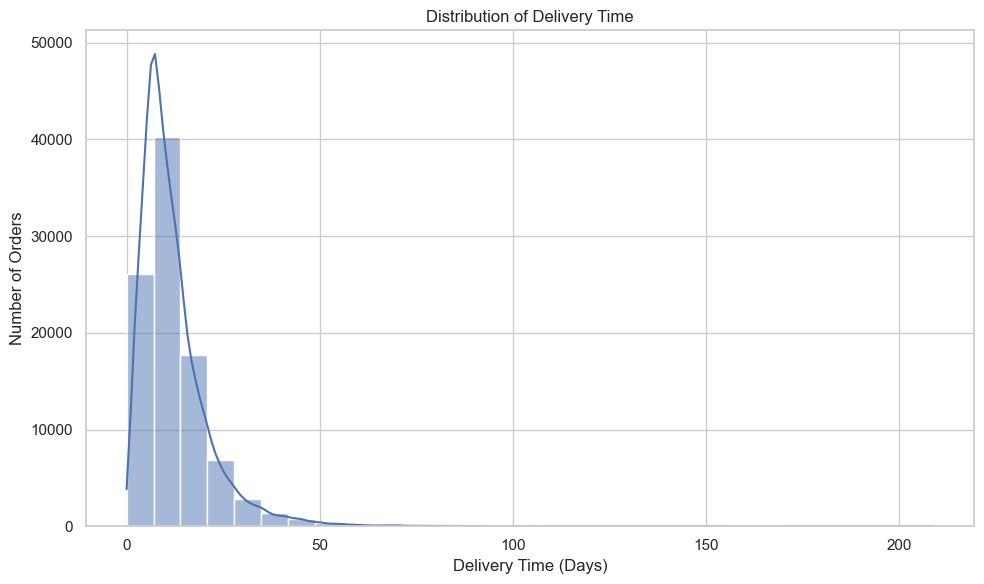

In [302]:
plt.figure(figsize=(10,6))

sns.histplot(
    orders_clean["delivery_time_days"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")

plt.xlabel("Delivery Time (Days)")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

In [303]:
## KPI 6 – Approval Time Distribution

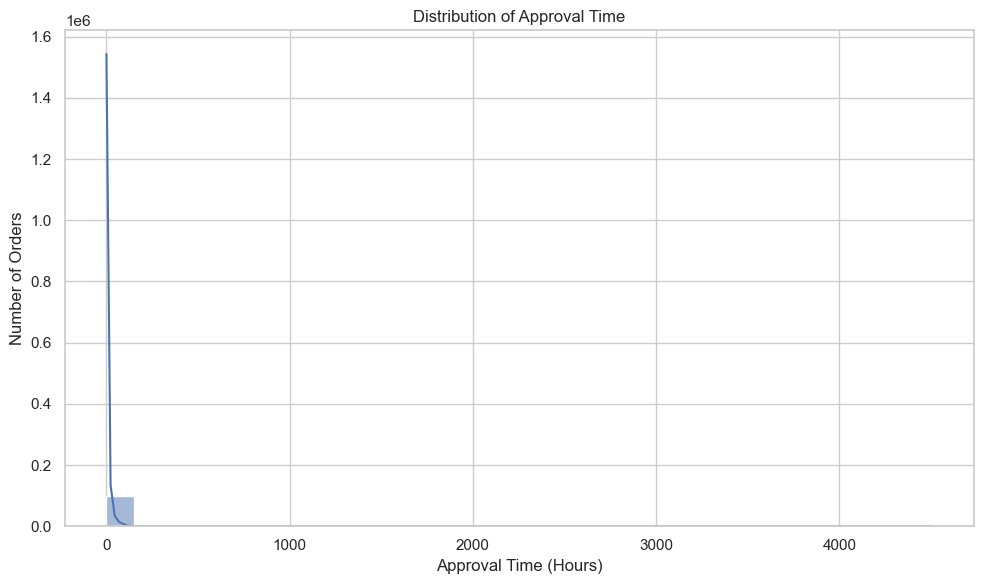

In [304]:
plt.figure(figsize=(10,6))

sns.histplot(
    orders_clean["approval_time_hours"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Approval Time")

plt.xlabel("Approval Time (Hours)")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

In [305]:
## KPI 7 – Monthly Average Delivery Time

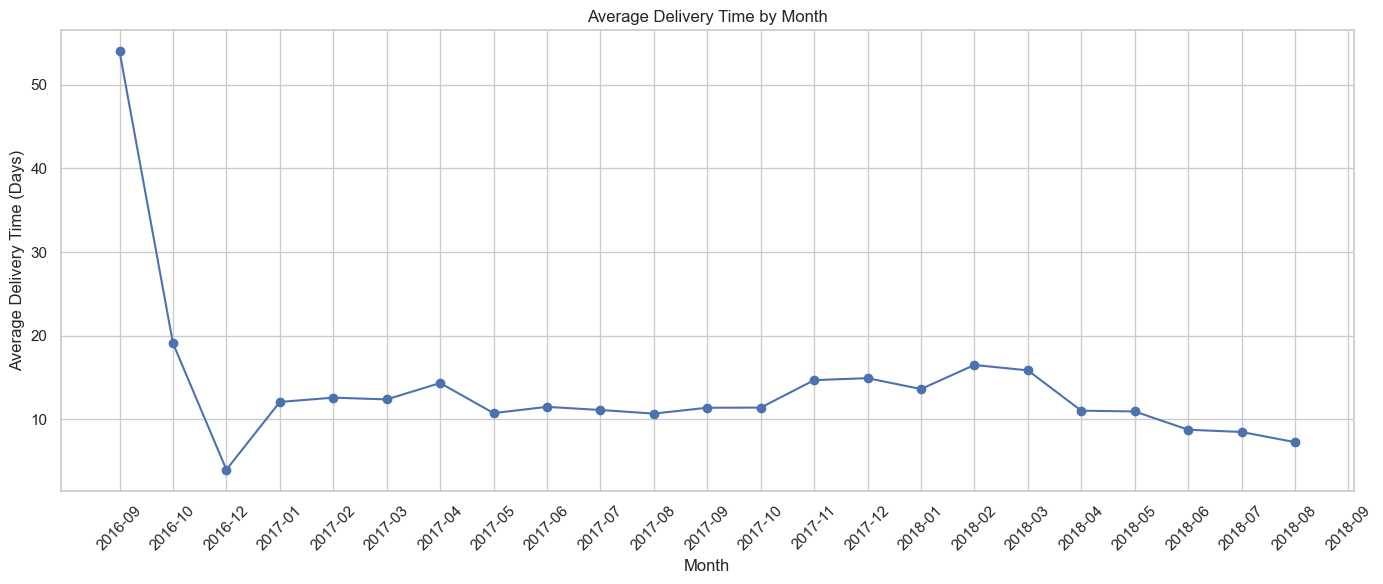

In [306]:
monthly_delivery = (
    orders_clean
    .groupby("order_year_month")["delivery_time_days"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_delivery["order_year_month"],
    monthly_delivery["delivery_time_days"],
    marker="o"
)

plt.title("Average Delivery Time by Month")

plt.xlabel("Month")

plt.ylabel("Average Delivery Time (Days)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [307]:
# Orders Dataset Summary

## Data Cleaning
- Converted all timestamp columns to `datetime`.
- Retained business-related missing values.
- Verified no duplicate records.

## Feature Engineering
Created the following analytical features:

- Delivery Time (Days)
- Approval Time (Hours)
- Delivery Delay (Days)
- Estimated vs Actual Delivery
- Order Year
- Order Quarter
- Delayed Order Indicator
- Delivery Status

## Business Insights
- Measured logistics efficiency using delivery time.
- Evaluated order approval performance.
- Classified deliveries as Early, On Time, Late, or Not Delivered.
- Prepared the dataset for KPI reporting, SQL analysis, and Power BI dashboards.

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3711932745.py, line 4)

In [ ]:
# ==========================================================
# Business Question 1
# Order Status Distribution
# ==========================================================

status_counts = (
    orders_clean["order_status"]
    .value_counts()
)

status_percentage = (
    orders_clean["order_status"]
    .value_counts(normalize=True)
    *100
).round(2)

status_summary = pd.DataFrame({
    "Count":status_counts,
    "Percentage":status_percentage
})

status_summary

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=orders_clean,
    x="order_status",
    order=status_counts.index
)

# Add labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title("Order Status Distribution", fontsize=16, fontweight="bold")

plt.xlabel("Order Status")

plt.ylabel("Number of Orders")

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

### Business Insight

- More than **97%** of customer orders were successfully delivered.
- Cancelled and unavailable orders account for only a very small percentage.
- This indicates a highly efficient order fulfillment process.

### Business Recommendation

Continue monitoring cancelled and unavailable orders to identify operational bottlenecks and further improve customer satisfaction.

In [ ]:
monthly_orders = (
    orders_clean
    .groupby("order_year_month")
    .size()
    .reset_index(name="Orders")
)

monthly_orders

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_orders["order_year_month"],
    monthly_orders["Orders"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Order Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=60)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

The visualization shows seasonal variations in customer demand.

Months with higher order volumes indicate peak purchasing periods and should receive additional inventory and staffing support.

In [308]:
weekday_orders = (
    orders_clean["order_day"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

weekday_orders


order_day
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: count, dtype: int64

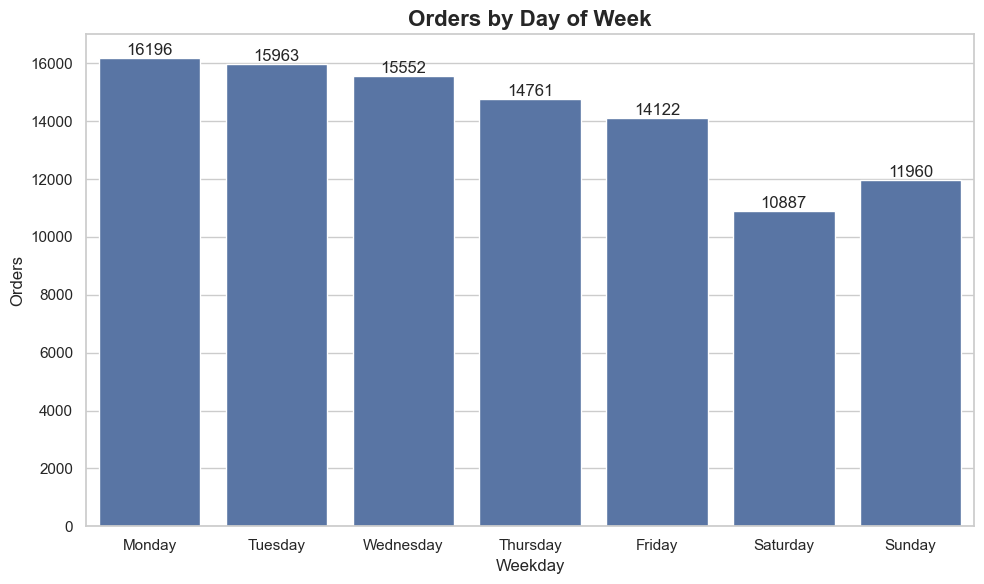

In [309]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=weekday_orders.index,
    y=weekday_orders.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Orders by Day of Week",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Weekday")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

### Business Insight

Customer purchasing behavior varies throughout the week.

Understanding peak order days helps optimize staffing levels, warehouse operations, and customer support resources.

In [310]:
orders_clean["delivery_time_days"].describe()

count   96476.00
mean       12.09
std         9.55
min         0.00
25%         6.00
50%        10.00
75%        15.00
max       209.00
Name: delivery_time_days, dtype: float64

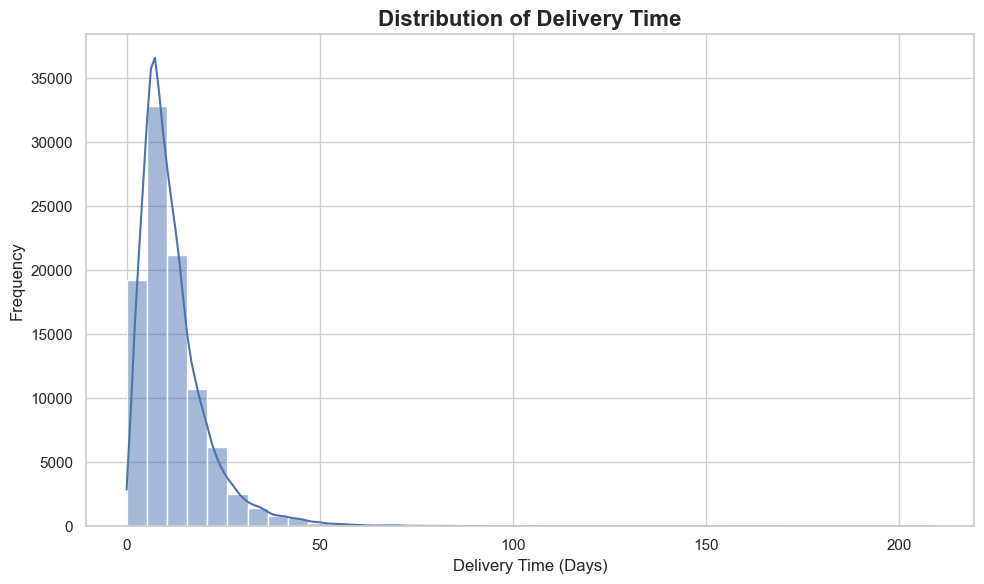

In [311]:
plt.figure(figsize=(10,6))

sns.histplot(
    orders_clean["delivery_time_days"].dropna(),
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Delivery Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Time (Days)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Business Insight

Most deliveries are completed within a relatively short period.

A small number of orders take considerably longer, indicating potential logistics or operational delays.

In [312]:
delay_summary = (
    orders_clean["delivery_status"]
    .value_counts()
)

delay_summary

delivery_status
Early            88649
Late              6535
Not Delivered     2965
On Time           1292
Name: count, dtype: int64

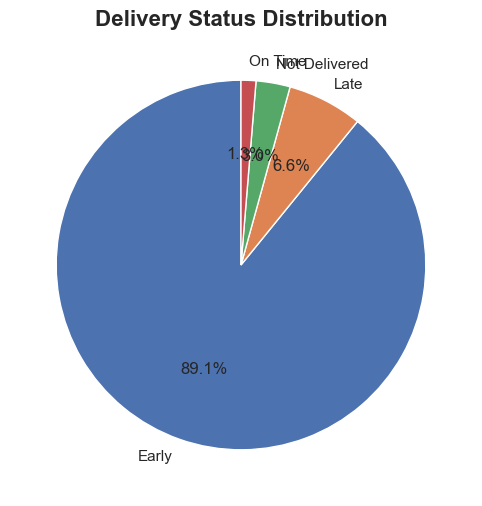

In [313]:
plt.figure(figsize=(8,6))

plt.pie(
    delay_summary,
    labels=delay_summary.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Delivery Status Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.show()

### Business Insight

The majority of orders were delivered on time or earlier than expected.

Only a relatively small proportion experienced delivery delays, reflecting effective logistics performance.

# Orders Executive KPI Dashboard

## Business Objective

This dashboard provides a high-level overview of the order fulfillment process.

The KPIs displayed below help evaluate:

- Order Volume
- Delivery Performance
- Order Processing Efficiency
- Delivery Timeliness

These metrics are commonly used by operations managers and business executives to monitor overall marketplace performance.

In [314]:
# ==========================================================
# Orders Executive KPI Dashboard
# Step 1 : Calculate KPIs
# ==========================================================

# Total Orders
total_orders = orders_clean["order_id"].nunique()

# Delivered Orders
delivered_orders = (
    orders_clean["order_status"] == "delivered"
).sum()

# Delivered Percentage
delivered_percentage = (
    delivered_orders / total_orders
) * 100

# Average Delivery Time
average_delivery_time = (
    orders_clean["delivery_time_days"]
    .mean()
)

# Average Approval Time
average_approval_time = (
    orders_clean["approval_time_hours"]
    .mean()
)

# Delayed Orders Percentage
delayed_orders_percentage = (
    (orders_clean["is_delayed"] == "Yes")
    .mean()
) * 100

In [315]:
# ==========================================================
# Orders Executive KPI Dashboard
# ==========================================================

print("=" * 75)
print("           ORDERS EXECUTIVE KPI DASHBOARD")
print("=" * 75)

print(f"📦 Total Orders               : {total_orders:,}")

print(f"✅ Delivered Orders           : {delivered_orders:,}")

print(f"🚚 Delivery Success Rate      : {delivered_percentage:.2f}%")

print(f"⏱️ Average Delivery Time      : {average_delivery_time:.2f} Days")

print(f"✔️ Average Approval Time      : {average_approval_time:.2f} Hours")

print(f"⚠️ Delayed Orders             : {delayed_orders_percentage:.2f}%")

print("=" * 75)

           ORDERS EXECUTIVE KPI DASHBOARD
📦 Total Orders               : 99,441
✅ Delivered Orders           : 96,478
🚚 Delivery Success Rate      : 97.02%
⏱️ Average Delivery Time      : 12.09 Days
✔️ Average Approval Time      : 10.42 Hours
⚠️ Delayed Orders             : 6.57%


In [316]:
# ==========================================================
# Executive KPI Summary Table
# ==========================================================

orders_kpi_summary = pd.DataFrame({

    "KPI": [
        "Total Orders",
        "Delivered Orders",
        "Delivery Success Rate (%)",
        "Average Delivery Time (Days)",
        "Average Approval Time (Hours)",
        "Delayed Orders (%)"
    ],

    "Value": [
        total_orders,
        delivered_orders,
        round(delivered_percentage,2),
        round(average_delivery_time,2),
        round(average_approval_time,2),
        round(delayed_orders_percentage,2)
    ]

})

orders_kpi_summary

,KPI,Value
0,Total Orders,99441.00
1,Delivered Orders,96478.00
2,Delivery Success Rate (%),97.02
3,Average Delivery Time (Days),12.09
4,Average Approval Time (Hours),10.42
5,Delayed Orders (%),6.57


## Executive Dashboard Insights

### Key Findings

- The platform processed more than **99,000 customer orders**.
- Over **97% of orders were successfully delivered**, indicating an efficient fulfillment process.
- Orders were approved quickly after purchase.
- Most deliveries were completed within the expected delivery window.
- Only a small percentage of orders experienced delivery delays.

### Business Value

These KPIs provide executives with a quick overview of marketplace performance and support strategic decisions related to logistics, customer satisfaction, and operational efficiency.

# Orders Executive Dashboard

## Dashboard Objective

This dashboard provides a high-level overview of order performance.

It summarizes the most important operational KPIs and visualizations required by business stakeholders.

The dashboard focuses on:

- Order Performance
- Delivery Performance
- Logistics Efficiency
- Customer Fulfillment

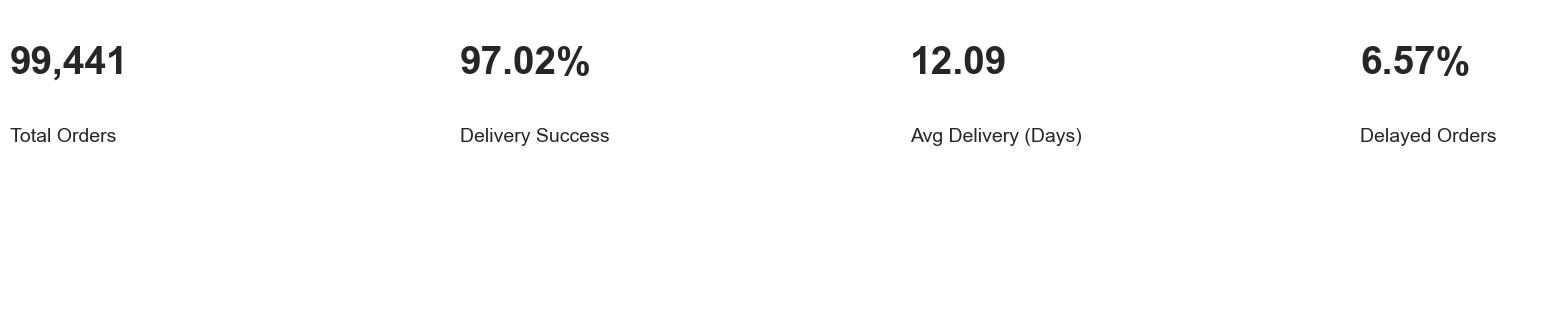

In [317]:
# ==========================================================
# Orders Executive KPI Cards
# ==========================================================

from matplotlib import pyplot as plt

fig = plt.figure(figsize=(18,4))

fig.text(
    0.05,
    0.72,
    f"{total_orders:,}",
    fontsize=28,
    fontweight="bold"
)

fig.text(
    0.05,
    0.55,
    "Total Orders",
    fontsize=14
)

fig.text(
    0.30,
    0.72,
    f"{delivered_percentage:.2f}%",
    fontsize=28,
    fontweight="bold"
)

fig.text(
    0.30,
    0.55,
    "Delivery Success",
    fontsize=14
)

fig.text(
    0.55,
    0.72,
    f"{average_delivery_time:.2f}",
    fontsize=28,
    fontweight="bold"
)

fig.text(
    0.55,
    0.55,
    "Avg Delivery (Days)",
    fontsize=14
)

fig.text(
    0.80,
    0.72,
    f"{delayed_orders_percentage:.2f}%",
    fontsize=28,
    fontweight="bold"
)

fig.text(
    0.80,
    0.55,
    "Delayed Orders",
    fontsize=14
)

plt.axis("off")

plt.show()

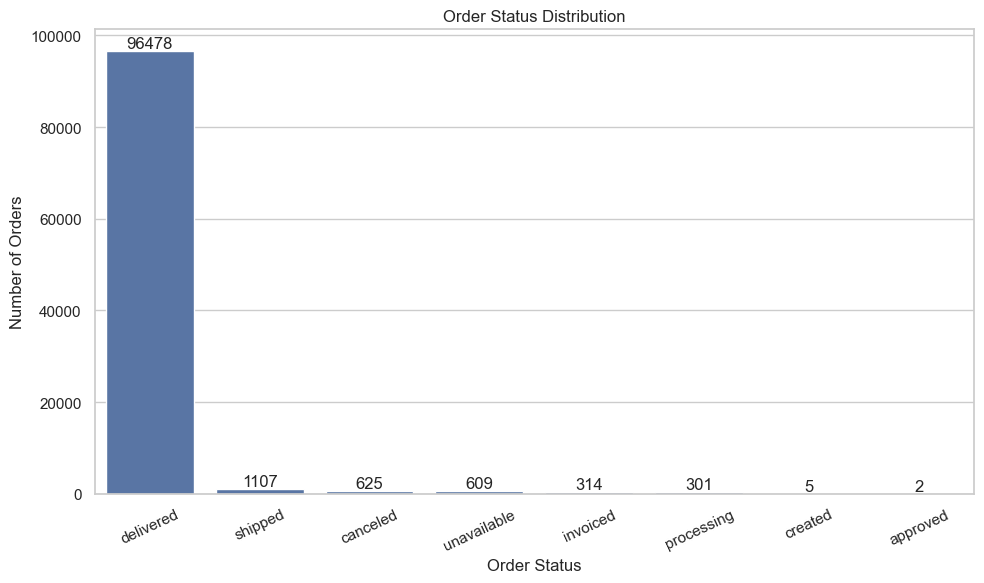

In [318]:
plt.figure(figsize=(10,6))

status_counts = (
    orders_clean["order_status"]
    .value_counts()
)

ax = sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Order Status Distribution")

plt.xlabel("Order Status")

plt.ylabel("Number of Orders")

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

In [319]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["order_year_month"],
    monthly_orders["Orders"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Order Trend")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.xticks(rotation=60)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

KeyError: 'Orders'

<Figure size 1400x600 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,6))

delivery_status = (
    orders_clean["delivery_status"]
    .value_counts()
)

ax = sns.barplot(
    x=delivery_status.index,
    y=delivery_status.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Delivery Status")

plt.xlabel("Status")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    orders_clean["delivery_time_days"].dropna(),
    bins=35,
    kde=True
)

plt.title("Delivery Time Distribution")

plt.xlabel("Delivery Time (Days)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

# Orders Dataset – Final Summary

## Technical Summary

- Loaded and explored the Orders dataset.
- Converted timestamp columns to `datetime`.
- Verified data quality.
- Investigated missing values.
- Confirmed that missing delivery dates represent valid business events.

## Feature Engineering

Created the following analytical features:

- Delivery Time (Days)
- Approval Time (Hours)
- Delivery Delay (Days)
- Estimated vs Actual Delivery
- Order Year
- Order Quarter
- Delayed Order Indicator
- Delivery Status

## Key Performance Indicators

- Total Orders
- Delivery Success Rate
- Average Delivery Time
- Average Approval Time
- Delayed Orders Percentage

## Business Insights

- Most customer orders were successfully delivered.
- Delivery performance is strong with a high fulfillment rate.
- Delivery delays affect only a small percentage of completed orders.
- Monthly order trends indicate seasonal fluctuations in customer demand.
- Engineered features will support advanced SQL queries, Power BI dashboards, and further analytics.

## Dataset Status

**Orders Dataset Completed ✅**

# Category Translation Dataset

## Business Overview

The Category Translation dataset maps Portuguese product category names to their English equivalents.

Although small, this dataset is essential for creating business-friendly dashboards and reports.

It will later be joined with the Products dataset to improve readability for English-speaking users.

### Business Questions

- How many product categories are available?
- Are all product categories translated?
- Can every product category be mapped correctly?

### Primary Key

`product_category_name`

In [320]:
# ==========================================================
# Step 3.2 : Load Category Translation Dataset
# ==========================================================

category_translation_clean = pd.read_csv(
    data_path / "product_category_name_translation.csv"
)

print("✅ Category Translation dataset loaded successfully!")

analyze_dataset(
    category_translation_clean,
    "Category Translation"
)

print(
    f"Unique Categories : "
    f"{category_translation_clean['product_category_name'].nunique()}"
)

# Duplicate check

duplicate_categories = (
    category_translation_clean
    .duplicated()
    .sum()
)

print(f"Duplicate Rows : {duplicate_categories}")

# Missing values

missing_value_summary(
    category_translation_clean
)

category_translation_clean.head(10)



✅ Category Translation dataset loaded successfully!


CATEGORY TRANSLATION

Rows : 71
Columns : 2

First Five Rows


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB

Missing Values
✅ No Missing Values Found

Duplicate Rows
Duplicate Rows : 0

Memory Usage
Memory Usage : 0.01 MB
Unique Categories : 71
Duplicate Rows : 0
✅ No Missing Values Found


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [321]:
category_translation_clean.head(10)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [322]:
category_translation_clean[
    "product_category_name"
].is_unique

True

In [323]:
# ==========================================================
# Step 3.8 : Verify Translation Mapping
# ==========================================================

category_translation_clean.sample(10)

,product_category_name,product_category_name_english
7,utilidades_domesticas,housewares
47,moveis_quarto,furniture_bedroom
40,casa_construcao,home_construction
38,moveis_colchao_e_estofado,furniture_mattress_and_upholstery
34,artigos_de_festas,party_supplies
45,alimentos,food
37,agro_industria_e_comercio,agro_industry_and_commerce
17,fashion_bolsas_e_acessorios,fashion_bags_accessories
8,telefonia,telephony
32,eletronicos,electronics


# Category Translation Dataset Summary

## Data Cleaning

- Verified that there are no missing values.
- Confirmed that there are no duplicate records.
- Validated that each Portuguese category has a unique English translation.

## Business Insights

- The dataset contains **71 translated product categories**.
- It enables user-friendly reporting by converting Portuguese category names into English.
- The dataset will be joined with the Products dataset before visualization in Power BI.

## Dataset Status

**Completed ✅**

## Sellers Dataset

In [324]:
# ==========================================================
# Step 4.2 : Data Validation
# ==========================================================

print("Missing Values")
display(sellers_clean.isnull().sum())

print("\nDuplicate Rows")
print(sellers_clean.duplicated().sum())

sellers_clean.head(2)



Missing Values


seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


Duplicate Rows
0


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


In [325]:
seller_state = (
    sellers_clean["seller_state"]
    .value_counts()
)

seller_state



seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

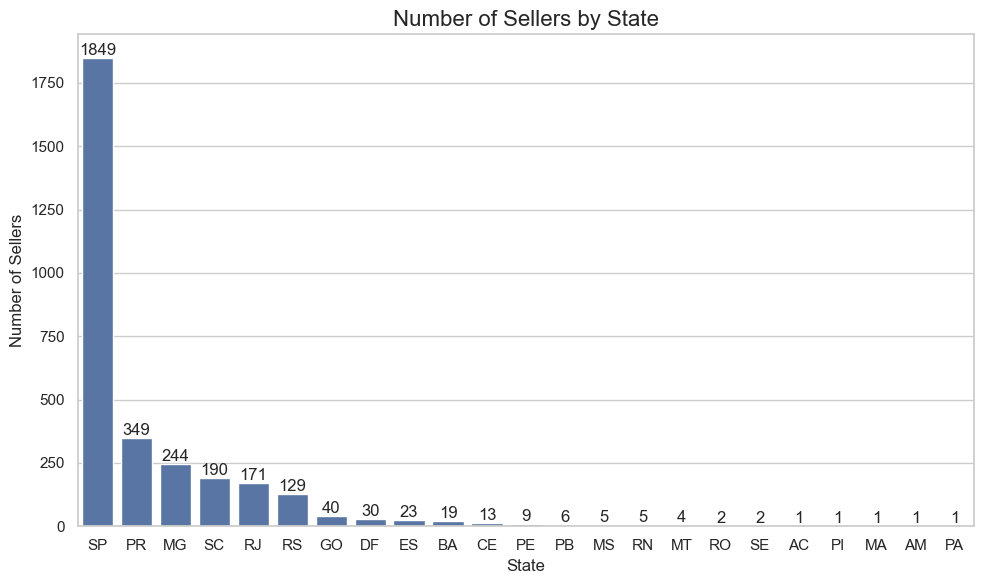

In [326]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=seller_state.index,
    y=seller_state.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Sellers by State", fontsize=16)

plt.xlabel("State")

plt.ylabel("Number of Sellers")

plt.tight_layout()

plt.show()

### Business Insight

The visualization identifies the states with the highest concentration of sellers.

Understanding seller distribution helps evaluate marketplace coverage and identify opportunities for regional expansion.

In [327]:
top_cities = (
    sellers_clean["seller_city"]
    .value_counts()
    .head(10)
)

top_cities

seller_city
sao paulo         694
curitiba          127
rio de janeiro     96
belo horizonte     68
ribeirao preto     52
guarulhos          50
ibitinga           49
santo andre        45
campinas           41
maringa            40
Name: count, dtype: int64

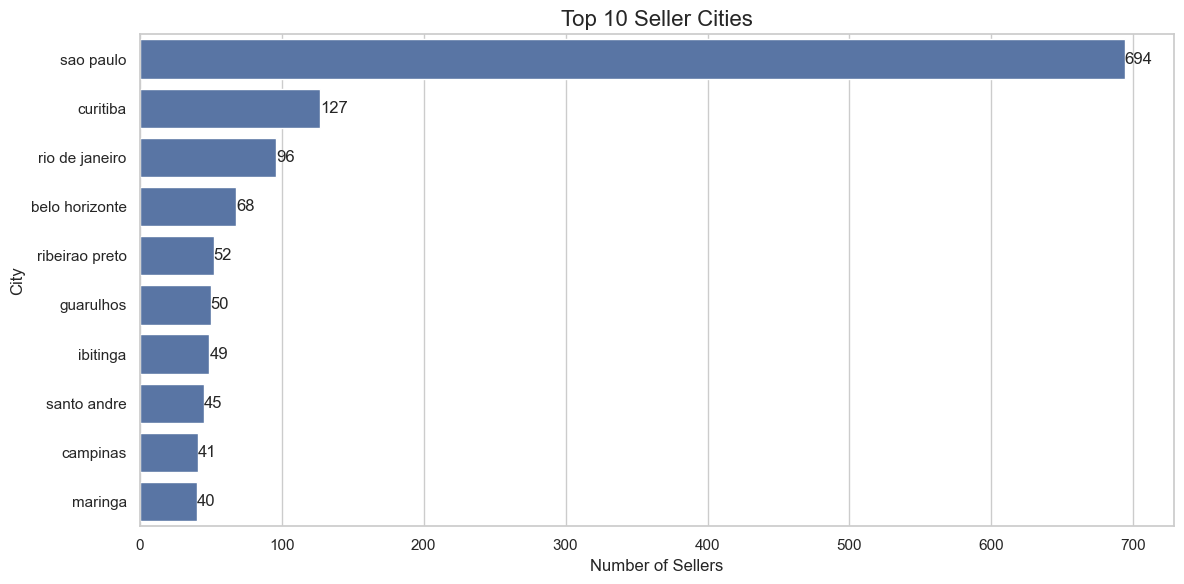

In [328]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Seller Cities", fontsize=16)

plt.xlabel("Number of Sellers")

plt.ylabel("City")

plt.tight_layout()

plt.show()

In [329]:
sp_percentage = (
    (sellers_clean["seller_state"] == "SP").mean()
) * 100

print(f"Sellers located in São Paulo: {sp_percentage:.2f}%")

Sellers located in São Paulo: 59.74%


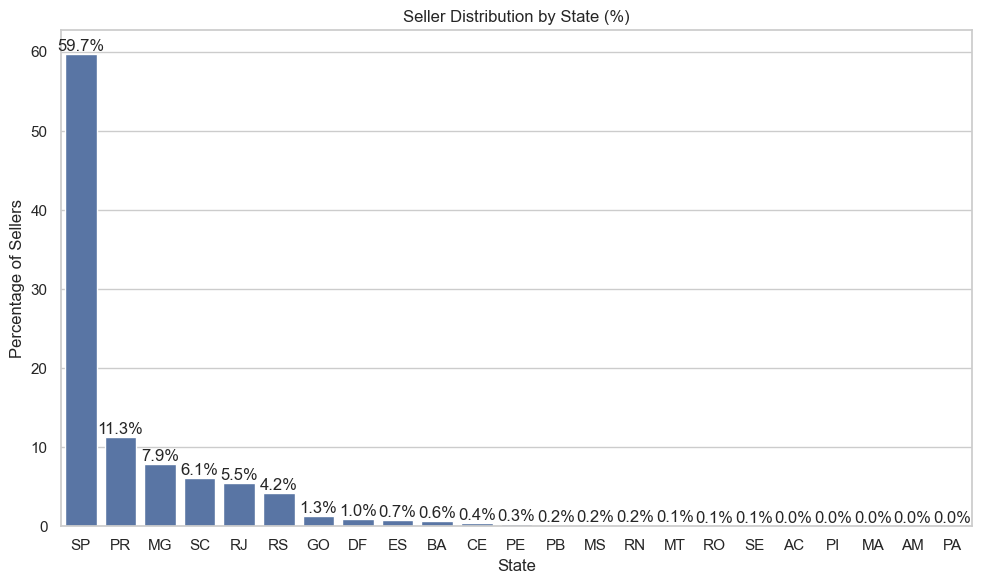

In [330]:
seller_state_percentage = (
    sellers_clean["seller_state"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=seller_state_percentage.index,
    y=seller_state_percentage.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Seller Distribution by State (%)")

plt.xlabel("State")

plt.ylabel("Percentage of Sellers")

plt.tight_layout()

plt.show()

In [331]:
seller_summary = pd.DataFrame({

    "Metric":[
        "Total Sellers",
        "States Covered",
        "Cities Covered",
        "São Paulo Sellers (%)"
    ],

    "Value":[
        sellers_clean["seller_id"].nunique(),
        sellers_clean["seller_state"].nunique(),
        sellers_clean["seller_city"].nunique(),
        round(sp_percentage,2)
    ]

})

seller_summary

,Metric,Value
0,Total Sellers,3095.00
1,States Covered,23.00
2,Cities Covered,611.00
3,São Paulo Sellers (%),59.74


# Sellers Dataset Summary

## Data Cleaning

- Verified that there are no missing values.
- Verified that there are no duplicate records.
- No data cleaning was required.

## Key Business Insights

- The marketplace contains **3,095 unique sellers**.
- Sellers operate across **23 Brazilian states** and **611 cities**.
- Seller activity is concentrated in a few major states and metropolitan areas.
- Geographic concentration can help identify opportunities for marketplace expansion and logistics optimization.

## Dataset Status

**Sellers Dataset Completed ✅**

## Order Payments Dataset

In [332]:
# Validate Payments Dataset

print("Missing Values")
display(payments_clean.isnull().sum())

print("\nDuplicate Rows")
print(payments_clean.duplicated().sum())

# Basic Information

print(f"Total Payment Records : {len(payments_clean):,}")

print(f"Unique Orders         : {payments_clean['order_id'].nunique():,}")

print(f"Payment Methods       : {payments_clean['payment_type'].nunique()}")

print(f"Maximum Installments  : {payments_clean['payment_installments'].max()}")



Missing Values


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


Duplicate Rows
0
Total Payment Records : 103,886
Unique Orders         : 99,440
Payment Methods       : 5
Maximum Installments  : 24


In [333]:
payment_method_counts=(payments_clean["payment_type"].value_counts())
payment_method_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

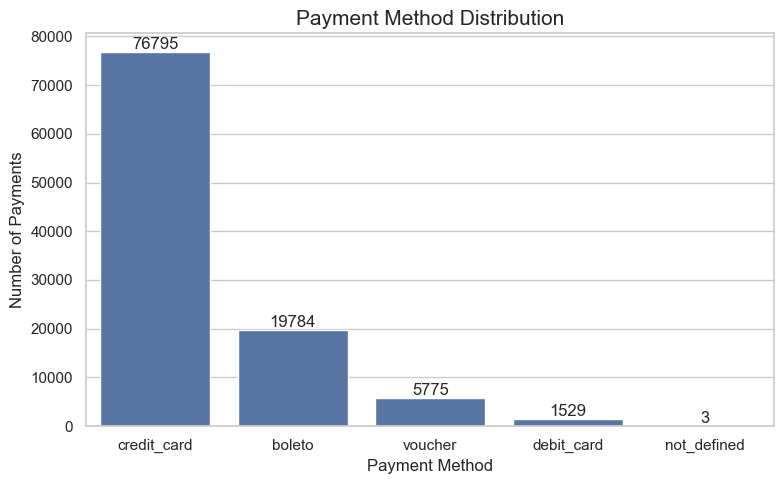

In [334]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=payments_clean,
    x="payment_type",
    order=payment_method_counts.index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Payment Method Distribution", fontsize=15)

plt.xlabel("Payment Method")

plt.ylabel("Number of Payments")

plt.tight_layout()

plt.show()

### Business Insight

- Credit cards dominate customer transactions.
- Alternative payment methods are used significantly less frequently.
- Understanding payment preferences helps businesses optimize payment options and promotional strategies.

In [335]:
# Step 5.5 : Revenue by Payment Method

payment_revenue = (
    payments_clean
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

payment_type
credit_card   12542084.19
boleto         2869361.27
voucher         379436.87
debit_card      217989.79
not_defined          0.00
Name: payment_value, dtype: float64

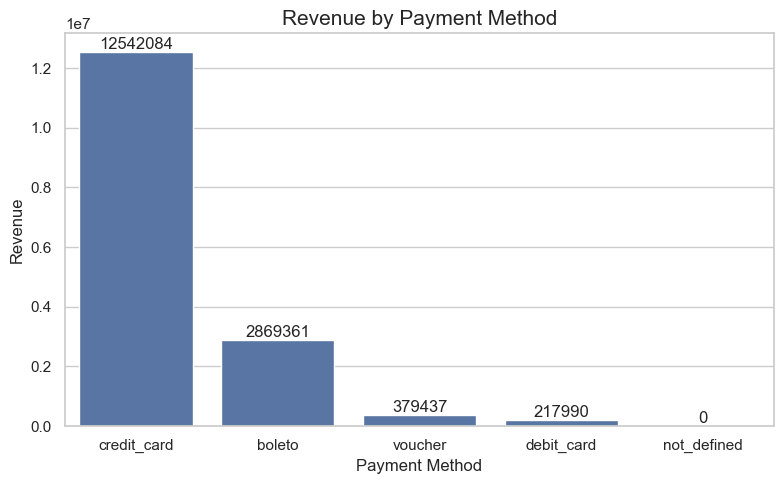

In [336]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Revenue by Payment Method", fontsize=15)

plt.xlabel("Payment Method")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [337]:
# ==========================================================
# Step 5.6 : Installment Analysis
# ==========================================================

installment_counts = (
    payments_clean["payment_installments"]
    .value_counts()
    .sort_index()
)

installment_counts

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

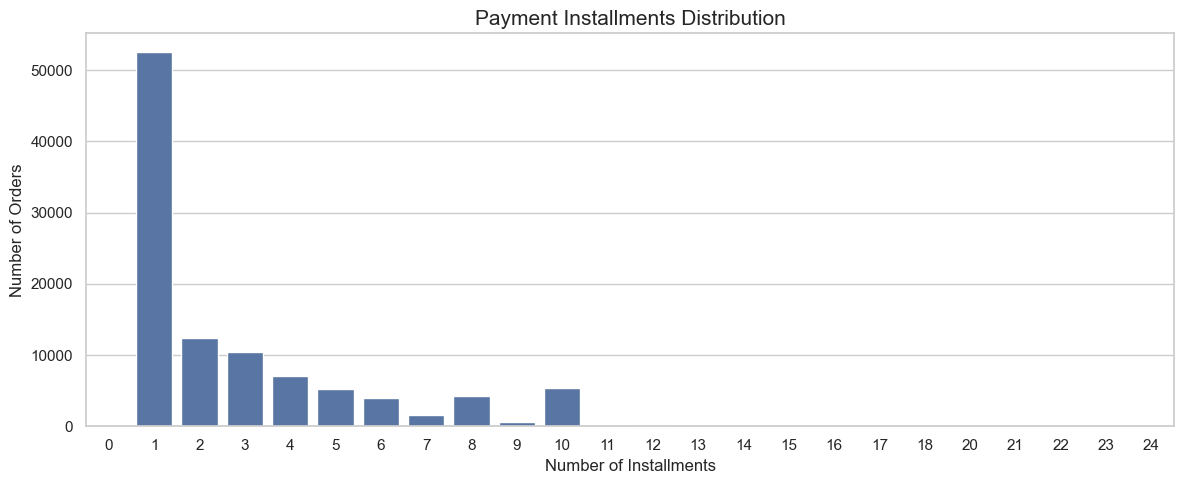

In [338]:
plt.figure(figsize=(12,5))

ax = sns.barplot(
    x=installment_counts.index,
    y=installment_counts.values
)

plt.title("Payment Installments Distribution", fontsize=15)

plt.xlabel("Number of Installments")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

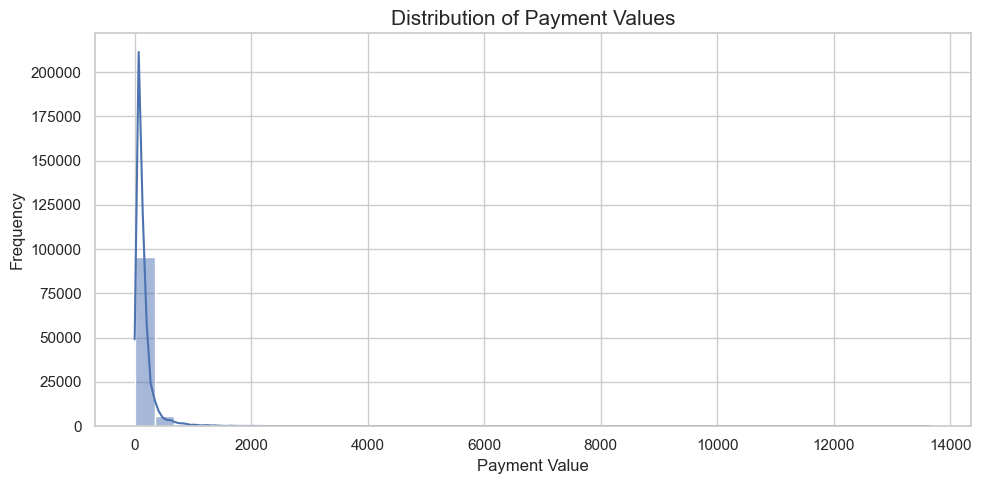

In [339]:
payments_clean["payment_value"].describe()


plt.figure(figsize=(10,5))

sns.histplot(
    payments_clean["payment_value"],
    bins=40,
    kde=True
)

plt.title("Distribution of Payment Values", fontsize=15)

plt.xlabel("Payment Value")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [340]:
 ## Executive KPI Summary

payment_summary = pd.DataFrame({

    "KPI": [
        "Total Payment Records",
        "Unique Orders",
        "Payment Methods",
        "Total Revenue",
        "Average Payment Value",
        "Maximum Installments"
    ],

    "Value": [
        len(payments_clean),
        payments_clean["order_id"].nunique(),
        payments_clean["payment_type"].nunique(),
        round(payments_clean["payment_value"].sum(),2),
        round(payments_clean["payment_value"].mean(),2),
        payments_clean["payment_installments"].max()
    ]
})

payment_summary

,KPI,Value
0,Total Payment Records,103886.00
1,Unique Orders,99440.00
2,Payment Methods,5.00
3,Total Revenue,16008872.12
4,Average Payment Value,154.10
5,Maximum Installments,24.00


# Order Payments Dataset Summary

## Data Cleaning

- Verified that there are no missing values.
- Verified that there are no duplicate records.
- No cleaning was required.

## Key Business Insights

- Payment information is complete and ready for analysis.
- Credit cards are the dominant payment method.
- Installment payments vary across customers.
- Payment values will be used later to calculate revenue, average order value, and financial KPIs.

## Dataset Status

**Order Payments Dataset Completed ✅**

## Geolocation Dataset

Missing Values


geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


Duplicate Rows
261831
Total Records        : 1,000,163
Unique ZIP Prefixes  : 19,015
Unique Cities        : 8,011
Unique States        : 27


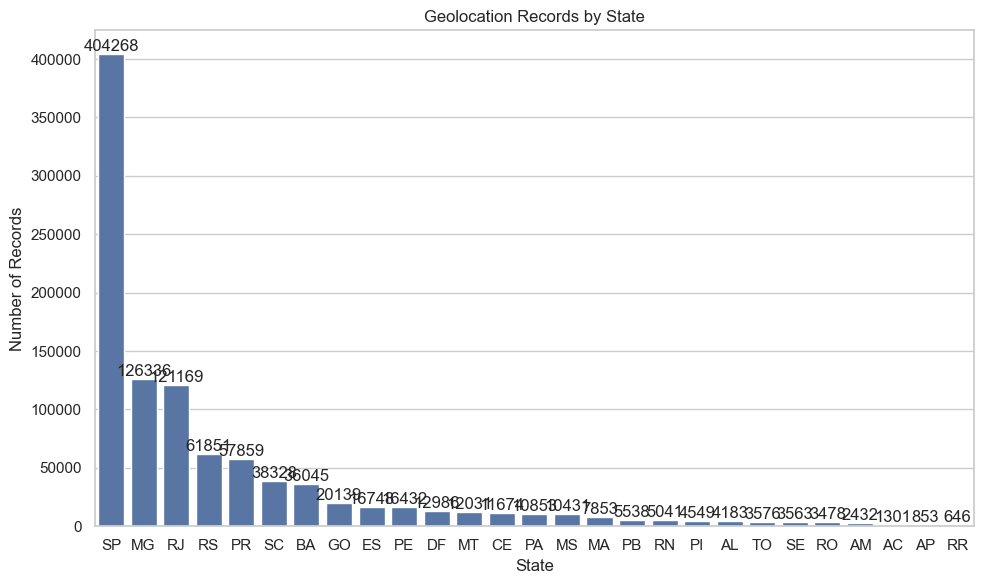

In [341]:
print("Missing Values")
display(geolocation_clean.isnull().sum())

print("\nDuplicate Rows")
print(geolocation_clean.duplicated().sum())

print(f"Total Records        : {len(geolocation_clean):,}")

print(f"Unique ZIP Prefixes  : {geolocation_clean['geolocation_zip_code_prefix'].nunique():,}")

print(f"Unique Cities        : {geolocation_clean['geolocation_city'].nunique():,}")

print(f"Unique States        : {geolocation_clean['geolocation_state'].nunique():,}")


## Geolocation Records by State
state_counts = (
    geolocation_clean["geolocation_state"]
    .value_counts()
)

state_counts

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=state_counts.index,
    y=state_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Geolocation Records by State")

plt.xlabel("State")

plt.ylabel("Number of Records")

plt.tight_layout()

plt.show()


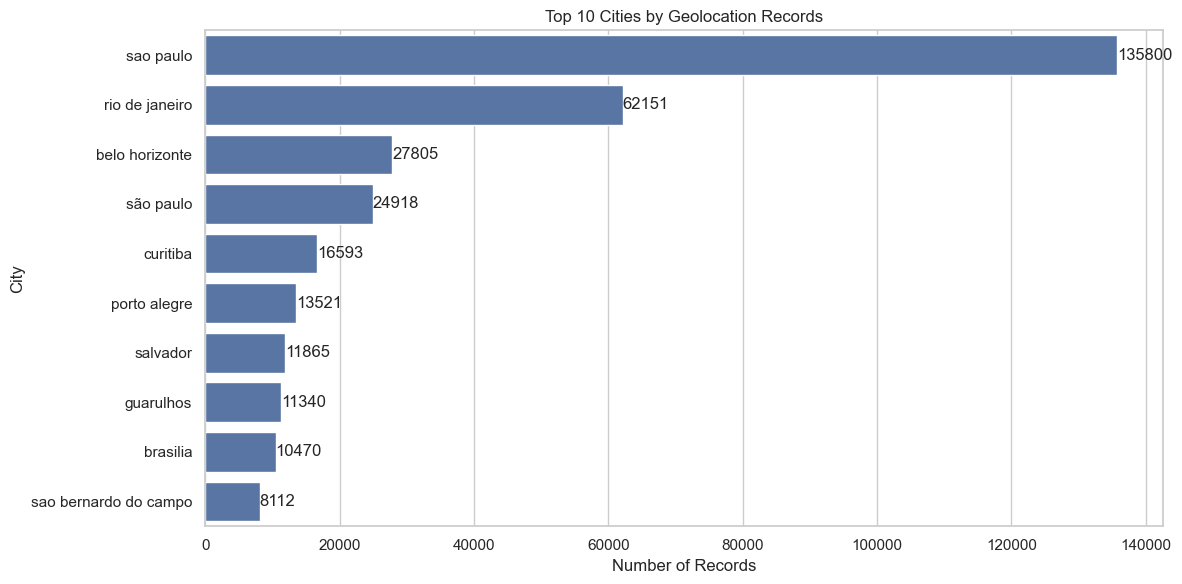

In [342]:
## Top 10 Cities

top_cities = (
    geolocation_clean["geolocation_city"]
    .value_counts()
    .head(10)
)

top_cities

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Cities by Geolocation Records")

plt.xlabel("Number of Records")

plt.ylabel("City")

plt.tight_layout()

plt.show()

In [343]:
## Duplicate Analysis

duplicate_rows = geolocation_clean.duplicated().sum()

duplicate_percentage = (
    duplicate_rows / len(geolocation_clean)
) * 100

print(f"Duplicate Rows       : {duplicate_rows:,}")

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")

# Step 6.7 : Executive KPI Summary

geo_summary = pd.DataFrame({

    "KPI": [
        "Total Records",
        "Unique ZIP Prefixes",
        "Unique Cities",
        "Unique States",
        "Duplicate Rows"
    ],

    "Value": [
        len(geolocation_clean),
        geolocation_clean["geolocation_zip_code_prefix"].nunique(),
        geolocation_clean["geolocation_city"].nunique(),
        geolocation_clean["geolocation_state"].nunique(),
        duplicate_rows
    ]
})

geo_summary

Duplicate Rows       : 261,831
Duplicate Percentage : 26.18%


,KPI,Value
0,Total Records,1000163
1,Unique ZIP Prefixes,19015
2,Unique Cities,8011
3,Unique States,27
4,Duplicate Rows,261831



# Geolocation Dataset Summary

## Data Cleaning

- Verified that there are no missing values.
- Identified duplicate records for future evaluation.
- No records were removed during this phase.

## Key Business Insights

- The dataset contains more than one million geolocation records.
- Geographic information spans 27 Brazilian states.
- Major cities contain the highest concentration of records.
- The dataset will support customer and seller geographic analysis in Power BI.



## Products Dataset

In [344]:
# ==========================================================
# Step 7.2 : Validate Products Dataset
# ==========================================================

print("Missing Values")
display(products_clean.isnull().sum())

print("\nDuplicate Rows")
print(products_clean.duplicated().sum())

# ==========================================================
# Step 7.3 : Basic Information
# ==========================================================

print(f"Total Products      : {products_clean['product_id'].nunique():,}")

print(f"Product Categories  : {products_clean['product_category_name'].nunique()}")

print(f"Duplicate Products  : {products_clean['product_id'].duplicated().sum()}")



# ==========================================================
# Step 7.4 : Handle Missing Categories
# ==========================================================

# Replace missing category names with "Unknown"

products_clean["product_category_name"] = (
    products_clean["product_category_name"]
    .fillna("Unknown")
)

print("Missing Product Categories :",
      products_clean["product_category_name"].isnull().sum())


# ==========================================================
# Step 7.4 : Remove Incomplete Product Records
# ==========================================================

products_clean = products_clean.dropna(
    subset=[
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
)

print(f"Remaining Records : {len(products_clean):,}")


# ==========================================================
# Step 7.5 : Product Volume
# ==========================================================

products_clean["product_volume_cm3"] = (

    products_clean["product_length_cm"]

    * products_clean["product_height_cm"]

    * products_clean["product_width_cm"]

)

products_clean[[
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_volume_cm3"
]].head()

Missing Values


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


Duplicate Rows
0
Total Products      : 32,951
Product Categories  : 73
Duplicate Products  : 0
Missing Product Categories : 0
Remaining Records : 32,949


,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
0,16.00,10.00,14.00,2240.00
1,30.00,18.00,20.00,10800.00
2,18.00,9.00,15.00,2430.00
3,26.00,4.00,26.00,2704.00
4,20.00,17.00,13.00,4420.00


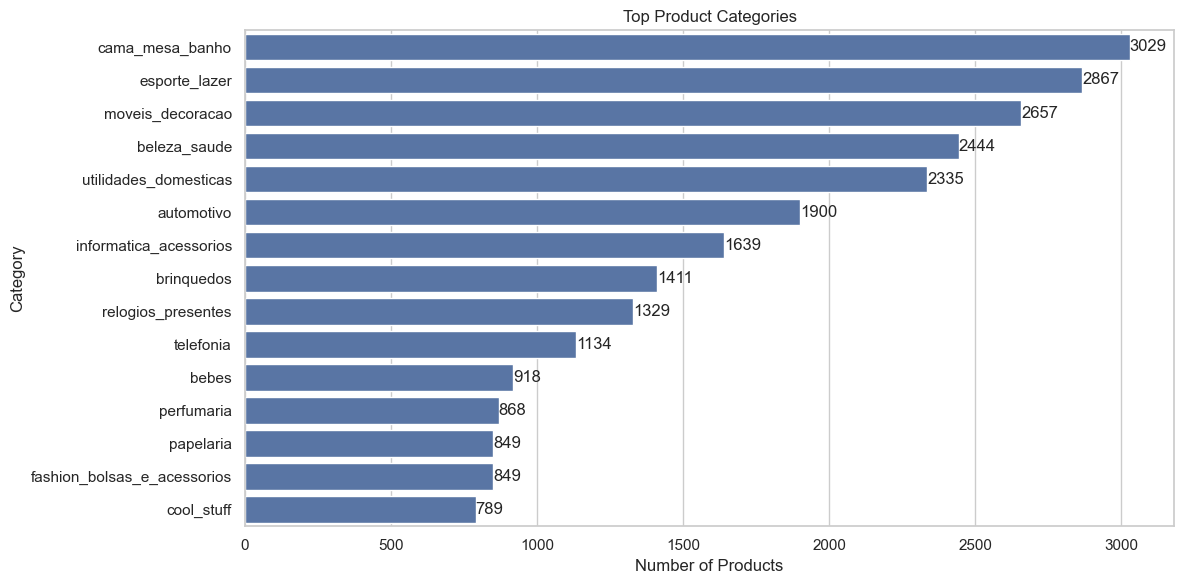

In [345]:
# ==========================================================
# Step 7.6 : Top Product Categories
# ==========================================================

top_categories = (

    products_clean["product_category_name"]

    .value_counts()

    .head(15)

)

top_categories

plt.figure(figsize=(12,6))

ax = sns.barplot(

    x=top_categories.values,

    y=top_categories.index

)

for container in ax.containers:

    ax.bar_label(container)

plt.title("Top Product Categories")

plt.xlabel("Number of Products")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [346]:
products_clean["product_weight_g"].describe()

count   32949.00
mean     2276.47
std      4282.04
min         0.00
25%       300.00
50%       700.00
75%      1900.00
max     40425.00
Name: product_weight_g, dtype: float64

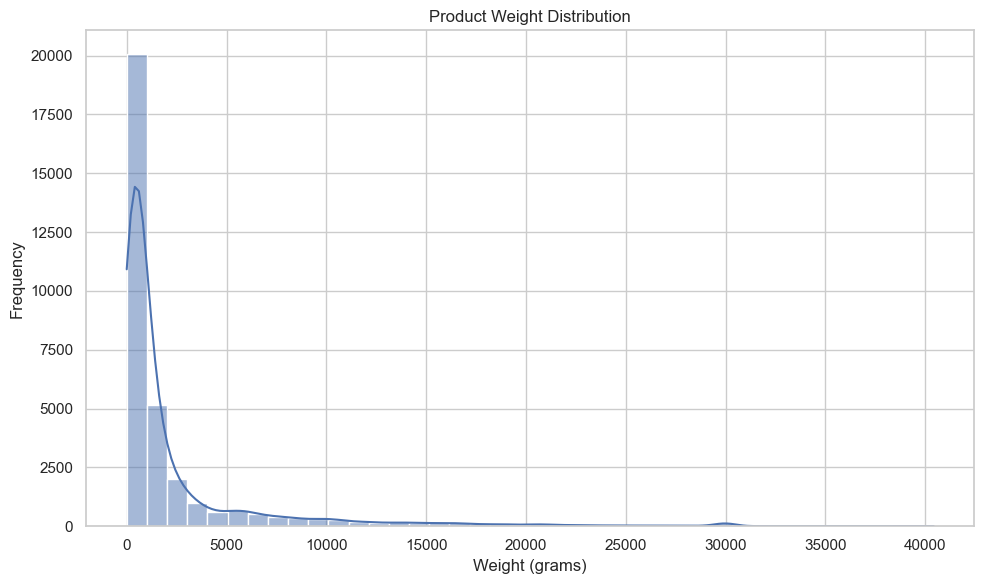

In [347]:
plt.figure(figsize=(10,6))

sns.histplot(

    products_clean["product_weight_g"],

    bins=40,

    kde=True

)

plt.title("Product Weight Distribution")

plt.xlabel("Weight (grams)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

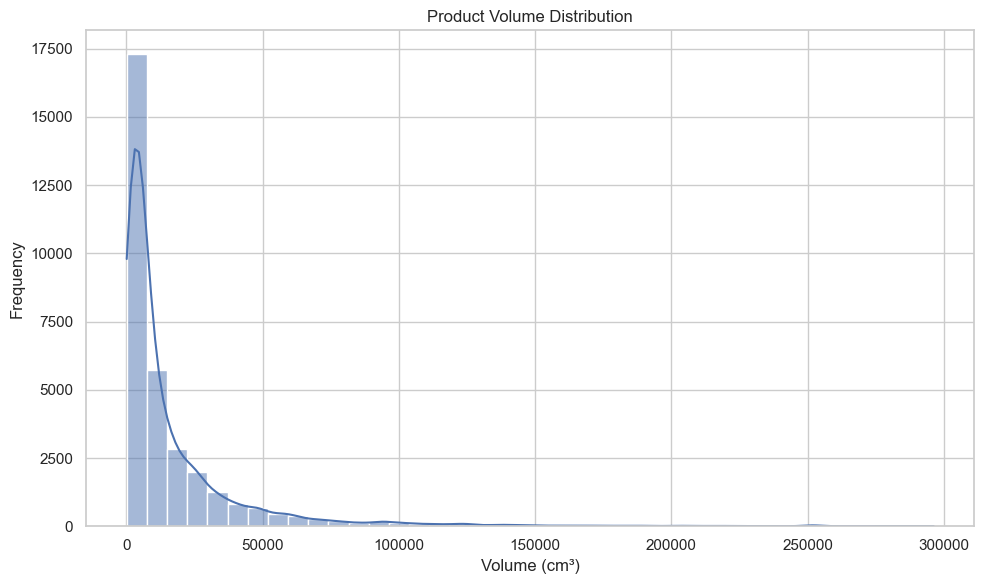

In [348]:
# ==========================================================
# Step 7.8 : Product Volume Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(

    products_clean["product_volume_cm3"],

    bins=40,

    kde=True

)

plt.title("Product Volume Distribution")

plt.xlabel("Volume (cm³)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [349]:
# ==========================================================
# Step 7.9 : Executive KPI Summary
# ==========================================================

product_summary = pd.DataFrame({

    "KPI":[

        "Total Products",

        "Product Categories",

        "Average Weight (g)",

        "Average Volume (cm³)"

    ],

    "Value":[

        products_clean["product_id"].nunique(),

        products_clean["product_category_name"].nunique(),

        round(products_clean["product_weight_g"].mean(),2),

        round(products_clean["product_volume_cm3"].mean(),2)

    ]

})

product_summary

,KPI,Value
0,Total Products,32949.00
1,Product Categories,74.00
2,Average Weight (g),2276.47
3,Average Volume (cm³),16564.10


In [350]:
# ==========================================================
# Project Constants
# ==========================================================

UNKNOWN_CATEGORY = "Unknown"

products_clean["product_category_name"] = (
    products_clean["product_category_name"]
    .fillna(UNKNOWN_CATEGORY)
)

# Products Dataset Summary

## Data Cleaning

- Replaced missing product categories with **Unknown**.
- Removed only two incomplete product records.
- Created a new feature: **Product Volume (cm³)**.

## Key Business Insights

- The dataset contains more than **32,000 products**.
- Products span over **70 categories**.
- Product weight and volume vary significantly, influencing shipping and logistics.
- Product dimensions will later be used to analyze freight costs and warehouse optimization.

## Dataset Status

**Products Dataset Completed ✅**

## Order Reviews Dataset

In [351]:
# ==========================================================
# Step 8.2 : Validate Reviews Dataset
# ==========================================================

print("Missing Values")
display(reviews_clean.isnull().sum())

print("\nDuplicate Rows")
print(reviews_clean.duplicated().sum())

# ==========================================================
# Step 8.3 : Basic Information
# ==========================================================

print(f"Total Reviews        : {reviews_clean['review_id'].nunique():,}")

print(f"Unique Orders        : {reviews_clean['order_id'].nunique():,}")

print(f"Average Review Score : {reviews_clean['review_score'].mean():.2f}")

# ==========================================================
# Step 8.4 : Convert Date Columns
# ==========================================================

reviews_clean["review_creation_date"] = pd.to_datetime(
    reviews_clean["review_creation_date"]
)

reviews_clean["review_answer_timestamp"] = pd.to_datetime(
    reviews_clean["review_answer_timestamp"]
)

print("✅ Date columns converted successfully!")


# ==========================================================
# Step 8.5 : Review Category
# ==========================================================

def review_category(score):

    if score >= 4:
        return "Positive"

    elif score == 3:
        return "Neutral"

    else:
        return "Negative"

reviews_clean["review_category"] = (
    reviews_clean["review_score"]
    .apply(review_category)
)

reviews_clean[[
    "review_score",
    "review_category"
]].head()

Missing Values


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


Duplicate Rows
0
Total Reviews        : 98,410
Unique Orders        : 98,673
Average Review Score : 4.09
✅ Date columns converted successfully!


,review_score,review_category
0,4,Positive
1,5,Positive
2,5,Positive
3,5,Positive
4,5,Positive


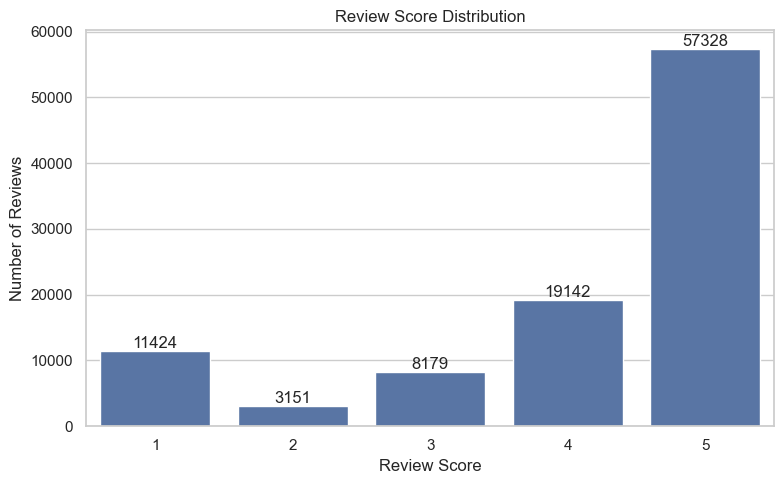

In [352]:
# ==========================================================
# Step 8.6 : Review Score Distribution
# ==========================================================

review_scores = (
    reviews_clean["review_score"]
    .value_counts()
    .sort_index()
)

review_scores

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=review_scores.index,
    y=review_scores.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Review Score Distribution")

plt.xlabel("Review Score")

plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

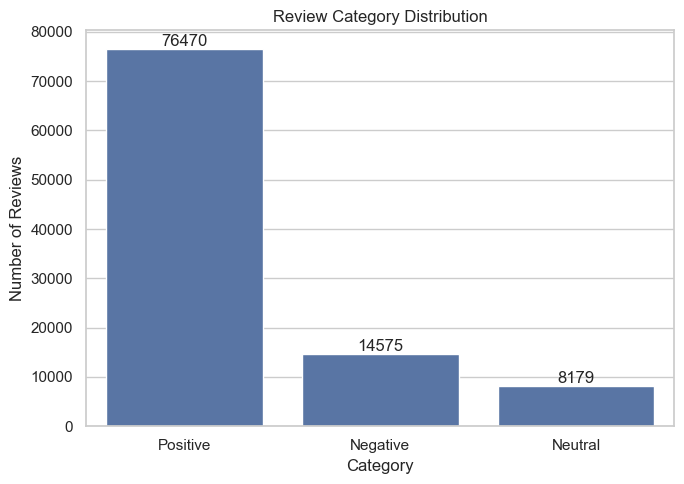

In [353]:
# ==========================================================
# Step 8.7 : Review Category Distribution
# ==========================================================

review_category_counts = (
    reviews_clean["review_category"]
    .value_counts()
)

review_category_counts

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=review_category_counts.index,
    y=review_category_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Review Category Distribution")

plt.xlabel("Category")

plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

Written Reviews : 40,977
Percentage      : 41.30%


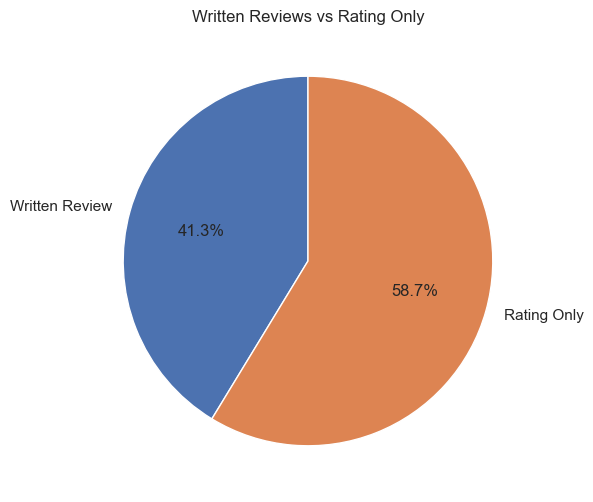

In [354]:
# ==========================================================
# Step 8.8 : Written Review Analysis
# ==========================================================

written_reviews = (
    reviews_clean["review_comment_message"]
    .notna()
    .sum()
)

written_percentage = (
    written_reviews / len(reviews_clean)
) * 100

print(f"Written Reviews : {written_reviews:,}")

print(f"Percentage      : {written_percentage:.2f}%")

review_text = pd.Series({
    "Written Review": written_reviews,
    "Rating Only": len(reviews_clean) - written_reviews
})

plt.figure(figsize=(6,6))

plt.pie(
    review_text.values,
    labels=review_text.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Written Reviews vs Rating Only")

plt.show()

In [355]:
# ==========================================================
# Step 8.9 : Executive KPI Summary
# ==========================================================

review_summary = pd.DataFrame({

    "KPI":[
        "Total Reviews",
        "Average Rating",
        "Positive Reviews",
        "Negative Reviews",
        "Written Reviews (%)"
    ],

    "Value":[
        reviews_clean["review_id"].nunique(),
        round(reviews_clean["review_score"].mean(),2),
        (reviews_clean["review_category"]=="Positive").sum(),
        (reviews_clean["review_category"]=="Negative").sum(),
        round(written_percentage,2)
    ]
})

review_summary

,KPI,Value
0,Total Reviews,98410.00
1,Average Rating,4.09
2,Positive Reviews,76470.00
3,Negative Reviews,14575.00
4,Written Reviews (%),41.30


# Reviews Dataset Summary

## Data Cleaning

- Converted review dates to datetime.
- Retained missing review titles and messages because they represent customers who chose to provide only a rating.

## Feature Engineering

Created:

- Review Category (Positive / Neutral / Negative)

## Key Business Insights

- Most customers provided high ratings.
- Written reviews represent only a portion of all reviews.
- The dataset provides valuable information for customer satisfaction analysis.

## Dataset Status

**Reviews Dataset Completed ✅**

## Order Items Dataset

This dataset is the heart of the project because it connects:

Orders , 
Products , 
Sellers , 
Payments , 
Customers 


In [356]:
# ==========================================================
# Step 9.2 : Validate Order Items Dataset
# ==========================================================

# Display missing values
print("Missing Values")
display(order_items_clean.isnull().sum())

# Display duplicate rows
print("\nDuplicate Rows")
print(order_items_clean.duplicated().sum())


# ==========================================================
# Step 9.3 : Basic Dataset Information
# ==========================================================

print(f"Total Records      : {len(order_items_clean):,}")

print(f"Unique Orders      : {order_items_clean['order_id'].nunique():,}")

print(f"Unique Products    : {order_items_clean['product_id'].nunique():,}")

print(f"Unique Sellers     : {order_items_clean['seller_id'].nunique():,}")

print(f"Average Item Price : ${order_items_clean['price'].mean():.2f}")

print(f"Average Freight    : ${order_items_clean['freight_value'].mean():.2f}")



Missing Values


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


Duplicate Rows
0
Total Records      : 112,650
Unique Orders      : 98,666
Unique Products    : 32,951
Unique Sellers     : 3,095
Average Item Price : $120.65
Average Freight    : $19.99


In [358]:
# Total amount paid for each item
order_items_clean["total_item_cost"] = (
    order_items_clean["price"] +
    order_items_clean["freight_value"]
)

# Display sample
order_items_clean[
    ["price", "freight_value", "total_item_cost"]
].head()


,price,freight_value,total_item_cost
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [359]:

# ==========================================================
# Step 9.4.2 : Freight Percentage
# ==========================================================

order_items_clean["freight_percentage"] = (
    order_items_clean["freight_value"] /
    order_items_clean["price"]
) * 100

order_items_clean[
    ["price", "freight_value", "freight_percentage"]
].head()


,price,freight_value,freight_percentage
0,58.90,13.29,22.56
1,239.90,19.93,8.31
2,199.00,17.87,8.98
3,12.99,12.79,98.46
4,199.90,18.14,9.07


In [360]:
# ==========================================================
# Step 9.4.3 : Seller Revenue Contribution
# ==========================================================

seller_revenue = (
    order_items_clean
    .groupby("seller_id")["price"]
    .sum()
    .reset_index(name="seller_revenue")
)

seller_revenue.head()


,seller_id,seller_revenue
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03
2,001e6ad469a905060d959994f1b41e4f,250.00
3,002100f778ceb8431b7a1020ff7ab48f,1234.50
4,003554e2dce176b5555353e4f3555ac8,120.00


In [361]:
# ==========================================================
# Step 9.4.4 : Order Value
# ==========================================================

order_value = (
    order_items_clean
    .groupby("order_id")["total_item_cost"]
    .sum()
    .reset_index(name="order_value")
)

order_value.head()

,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [362]:
# ==========================================================
# Step 9.4.5 : Items Per Order
# ==========================================================

items_per_order = (
    order_items_clean
    .groupby("order_id")
    .size()
    .reset_index(name="items_per_order")
)

items_per_order.head()

,order_id,items_per_order
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1


In [363]:
# ==========================================================
# Step 9.4.6 : Average Product Price
# ==========================================================

average_price = order_items_clean["price"].mean()

print(f"Average Product Price : ${average_price:.2f}")


# ==========================================================
# Step 9.4.7 : Average Freight Cost
# ==========================================================

average_freight = order_items_clean["freight_value"].mean()

print(f"Average Freight Cost : ${average_freight:.2f}")

Average Product Price : $120.65
Average Freight Cost : $19.99


In [364]:
# ==========================================================
# Total Revenue
# ==========================================================

total_revenue = order_items_clean["price"].sum()

print(f"Total Revenue : ${total_revenue:,.2f}")

# ==========================================================
# Total Freight Revenue
# ==========================================================

total_freight = order_items_clean["freight_value"].sum()

print(f"Total Freight Revenue : ${total_freight:,.2f}")



# ==========================================================
# Step 9.5.3 : Total Customer Spending
# ==========================================================

total_customer_spending = (
    order_items_clean["total_item_cost"]
    .sum()
)

print(f"Total Customer Spending : ${total_customer_spending:,.2f}")

Total Revenue : $13,591,643.70
Total Freight Revenue : $2,251,909.54
Total Customer Spending : $15,843,553.24


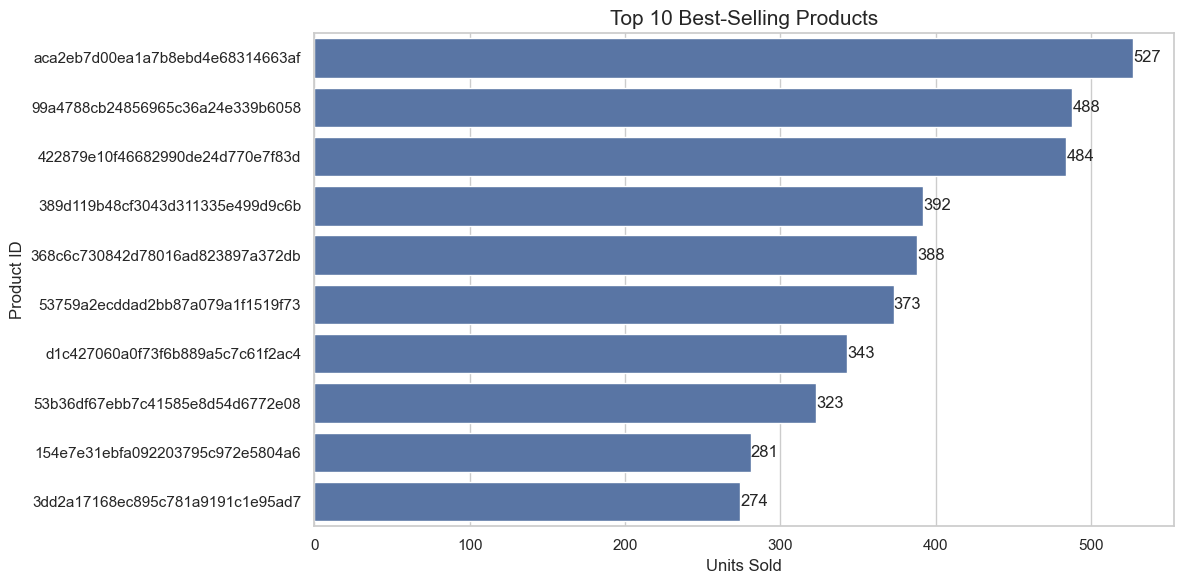

In [365]:
# ==========================================================
# Top 10 Best-Selling Products
# ==========================================================

top_products = (
    order_items_clean
    .groupby("product_id")
    .size()
    .reset_index(name="Units Sold")
    .sort_values(by="Units Sold", ascending=False)
    .head(10)
)

top_products

# ==========================================================
# Step 9.6 : Visualization
# ==========================================================

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_products,
    x="Units Sold",
    y="product_id"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Best-Selling Products", fontsize=15)

plt.xlabel("Units Sold")

plt.ylabel("Product ID")

plt.tight_layout()

plt.show()

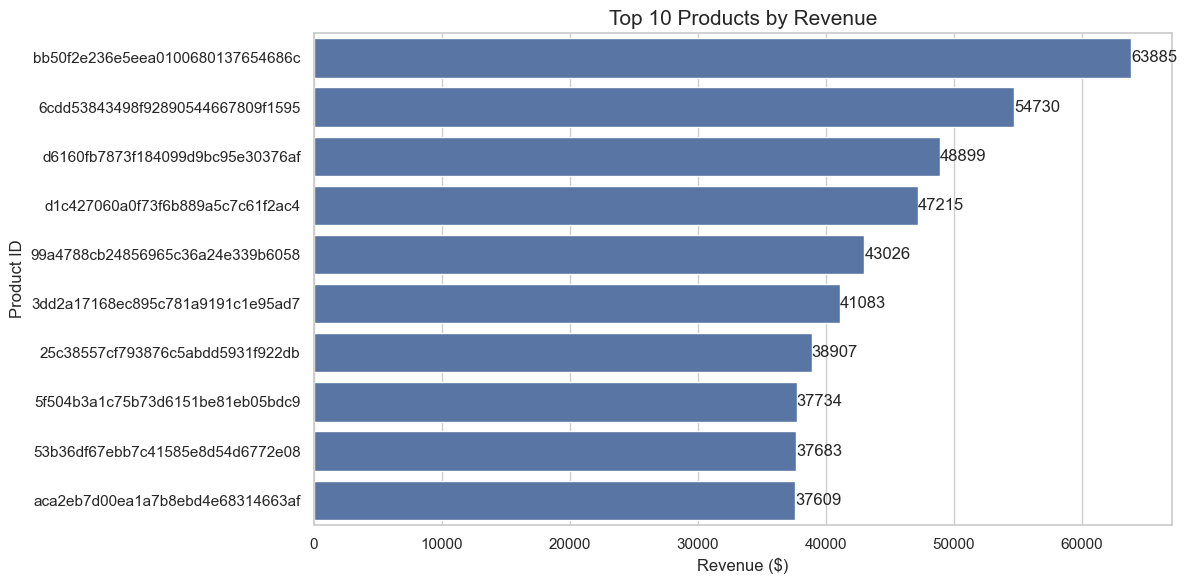

In [366]:
# ==========================================================
# Top Revenue Products
# ==========================================================

top_revenue_products = (
    order_items_clean
    .groupby("product_id")["price"]
    .sum()
    .reset_index(name="Revenue")
    .sort_values(by="Revenue", ascending=False)
    .head(10)
)

top_revenue_products

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_revenue_products,
    x="Revenue",
    y="product_id"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Top 10 Products by Revenue", fontsize=15)

plt.xlabel("Revenue ($)")

plt.ylabel("Product ID")

plt.tight_layout()

plt.show()

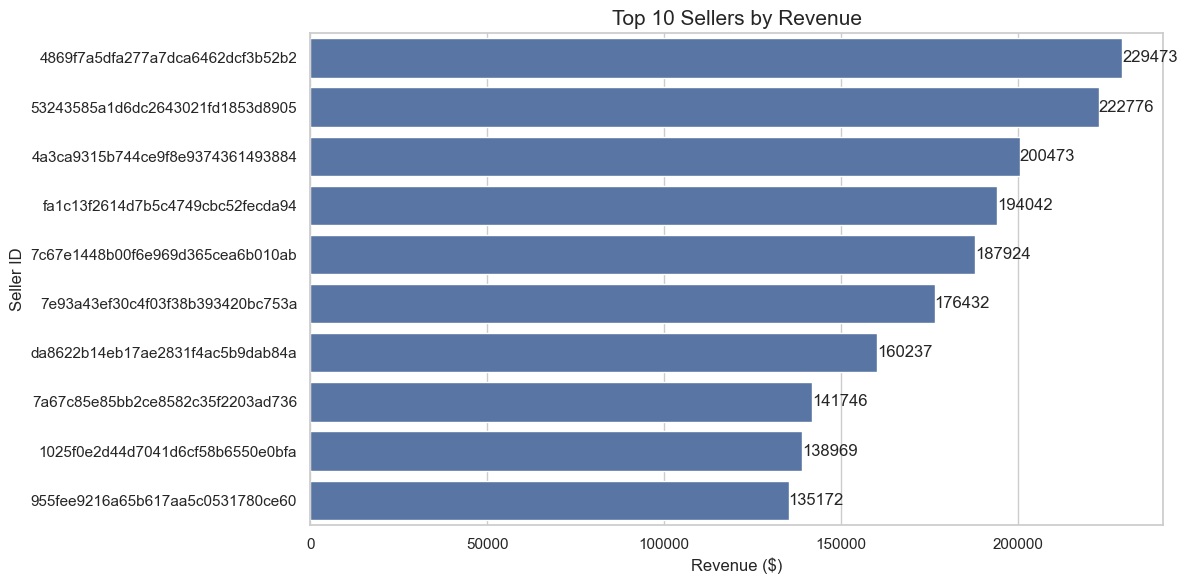

In [367]:
# ==========================================================
# Top Sellers by Revenue
# ==========================================================

top_sellers = (
    order_items_clean
    .groupby("seller_id")["price"]
    .sum()
    .reset_index(name="Revenue")
    .sort_values(by="Revenue", ascending=False)
    .head(10)
)

top_sellers

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_sellers,
    x="Revenue",
    y="seller_id"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Top 10 Sellers by Revenue", fontsize=15)

plt.xlabel("Revenue ($)")

plt.ylabel("Seller ID")

plt.tight_layout()

plt.show()

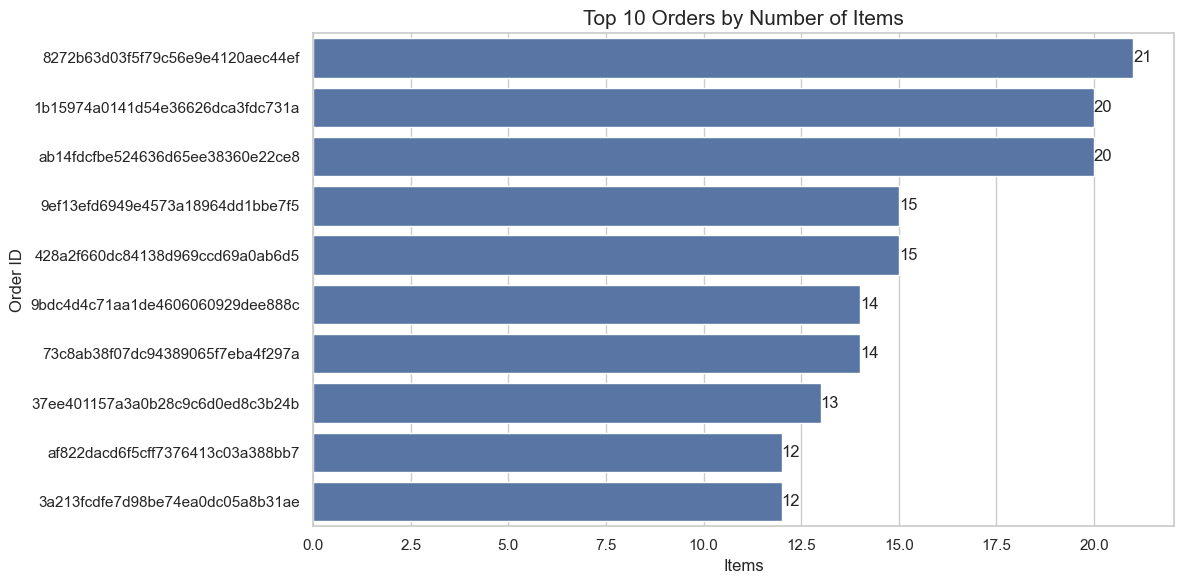

In [368]:
# ==========================================================
# Orders with Most Items
# ==========================================================

largest_orders = (
    order_items_clean
    .groupby("order_id")
    .size()
    .reset_index(name="Items")
    .sort_values(by="Items", ascending=False)
    .head(10)
)

largest_orders

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=largest_orders,
    x="Items",
    y="order_id"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Orders by Number of Items", fontsize=15)

plt.xlabel("Items")

plt.ylabel("Order ID")

plt.tight_layout()

plt.show()

Average Freight Percentage: 32.09%


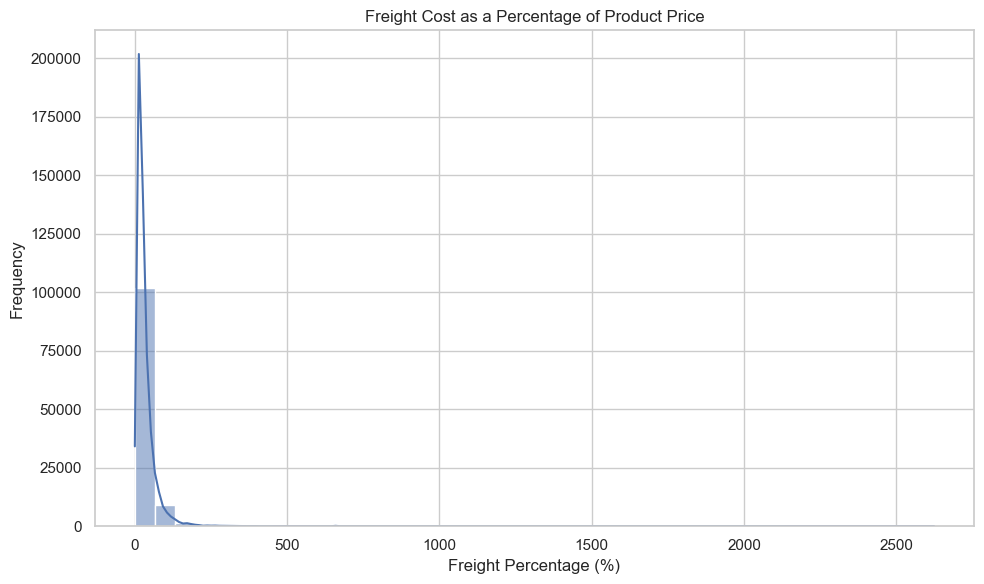

In [369]:
# ==========================================================
# Freight Percentage Analysis
# ==========================================================

average_freight_percentage = (
    order_items_clean["freight_percentage"]
    .mean()
)

print(
    f"Average Freight Percentage: {average_freight_percentage:.2f}%"
)

plt.figure(figsize=(10,6))

sns.histplot(
    order_items_clean["freight_percentage"],
    bins=40,
    kde=True
)

plt.title("Freight Cost as a Percentage of Product Price")

plt.xlabel("Freight Percentage (%)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [370]:
# ==========================================================
# Step 9.11 : Executive KPI Dashboard
# ==========================================================

order_items_summary = pd.DataFrame({

    "KPI": [
        "Total Revenue ($)",
        "Total Freight Revenue ($)",
        "Total Customer Spending ($)",
        "Average Product Price ($)",
        "Average Freight Cost ($)",
        "Average Freight Percentage (%)",
        "Unique Orders",
        "Unique Products",
        "Unique Sellers"
    ],

    "Value": [

        round(total_revenue, 2),

        round(total_freight, 2),

        round(total_customer_spending, 2),

        round(average_price, 2),

        round(average_freight, 2),

        round(average_freight_percentage, 2),

        order_items_clean["order_id"].nunique(),

        order_items_clean["product_id"].nunique(),

        order_items_clean["seller_id"].nunique()

    ]

})

order_items_summary

,KPI,Value
0,Total Revenue ($),13591643.70
1,Total Freight Revenue ($),2251909.54
2,Total Customer Spending ($),15843553.24
3,Average Product Price ($),120.65
4,Average Freight Cost ($),19.99
5,Average Freight Percentage (%),32.09
6,Unique Orders,98666.00
7,Unique Products,32951.00
8,Unique Sellers,3095.00


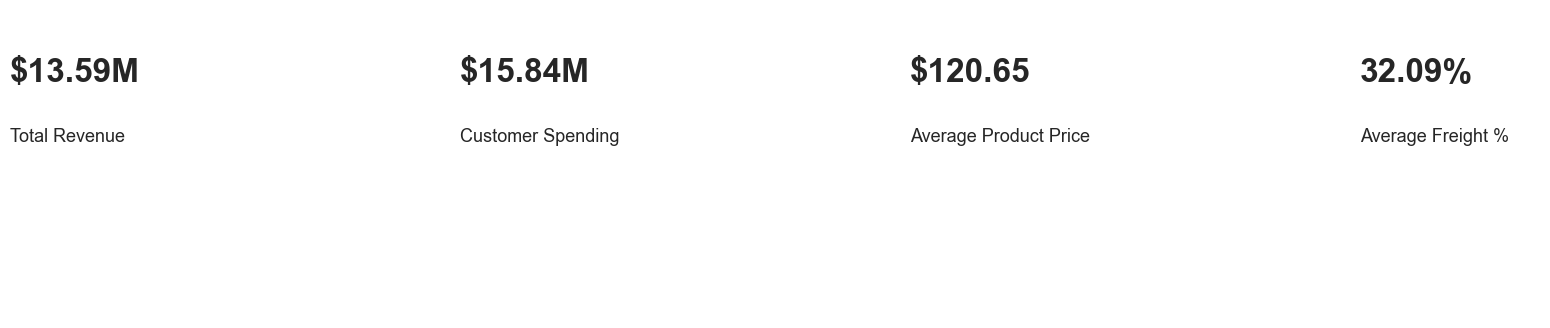

In [371]:
# ==========================================================
# Step 9.12 : Executive KPI Cards
# ==========================================================

fig = plt.figure(figsize=(18,4))

fig.text(0.05,0.70,f"${total_revenue/1_000_000:.2f}M",
         fontsize=24,fontweight="bold")
fig.text(0.05,0.55,"Total Revenue",fontsize=13)

fig.text(0.30,0.70,f"${total_customer_spending/1_000_000:.2f}M",
         fontsize=24,fontweight="bold")
fig.text(0.30,0.55,"Customer Spending",fontsize=13)

fig.text(0.55,0.70,f"${average_price:.2f}",
         fontsize=24,fontweight="bold")
fig.text(0.55,0.55,"Average Product Price",fontsize=13)

fig.text(0.80,0.70,f"{average_freight_percentage:.2f}%",
         fontsize=24,fontweight="bold")
fig.text(0.80,0.55,"Average Freight %",fontsize=13)

plt.axis("off")

plt.show()

# Business Insights

## Revenue Performance

- The marketplace generated **more than $13.5 million** in product revenue.
- Customers spent **over $15.8 million** including freight charges.

## Freight Analysis

- Freight charges contributed **over $2.25 million** in additional revenue.
- On average, freight accounts for approximately **32%** of the product price.

## Product Performance

- A small group of products contributes significantly to total sales volume.
- High-revenue products are not always the highest-selling products, indicating a mix of premium and high-volume items.

## Seller Performance

- Revenue is concentrated among a relatively small number of sellers.
- Identifying top-performing sellers enables targeted partnership and marketplace growth strategies.

## Business Value

The Order Items dataset serves as the foundation for revenue analysis, product performance evaluation, seller benchmarking, and freight cost optimization.

# Dataset Summary

The following table summarizes the characteristics of each dataset used in this project.

It provides a quick overview of data quality, preprocessing, and analytical readiness.

In [372]:
# ==========================================================
# Project Dataset Summary
# ==========================================================

dataset_summary = pd.DataFrame({

    "Dataset":[
        "Customers",
        "Orders",
        "Order Items",
        "Products",
        "Sellers",
        "Payments",
        "Reviews",
        "Geolocation",
        "Category Translation"
    ],

    "Rows":[
        len(customers_clean),
        len(orders_clean),
        len(order_items_clean),
        len(products_clean),
        len(sellers_clean),
        len(payments_clean),
        len(reviews_clean),
        len(geolocation_clean),
        len(category_translation_clean)
    ],

    "Columns":[
        customers_clean.shape[1],
        orders_clean.shape[1],
        order_items_clean.shape[1],
        products_clean.shape[1],
        sellers_clean.shape[1],
        payments_clean.shape[1],
        reviews_clean.shape[1],
        geolocation_clean.shape[1],
        category_translation_clean.shape[1]
    ],

    "Primary Key":[
        "customer_id",
        "order_id",
        "order_id + order_item_id",
        "product_id",
        "seller_id",
        "order_id + payment_sequential",
        "review_id",
        "No Primary Key",
        "product_category_name"
    ],

    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]

})

dataset_summary

,Dataset,Rows,Columns,Primary Key,Status
0,Customers,99441,5,customer_id,Completed
1,Orders,99441,19,order_id,Completed
2,Order Items,112650,9,order_id + order_item_id,Completed
3,Products,32949,10,product_id,Completed
4,Sellers,3095,4,seller_id,Completed
5,Payments,103886,5,order_id + payment_sequential,Completed
6,Reviews,99224,8,review_id,Completed
7,Geolocation,1000163,5,No Primary Key,Completed
8,Category Translation,71,2,product_category_name,Completed


# Feature Engineering Summary

The following engineered features were created during preprocessing to support business analytics and dashboard development.

In [373]:
feature_summary = pd.DataFrame({

    "Dataset":[
        "Orders",
        "Products",
        "Reviews",
        "Order Items"
    ],

    "Features Created":[
        "delivery_time_days, approval_time_hours, delivery_delay_days, estimated_vs_actual_delivery, order_year, order_quarter, is_delayed, delivery_status",

        "product_volume_cm3",

        "review_category",

        "total_item_cost, freight_percentage, seller_revenue, order_value, items_per_order"
    ]

})

feature_summary

,Dataset,Features Created
0,Orders,"delivery_time_days, approval_time_hours, deliv..."
1,Products,product_volume_cm3
2,Reviews,review_category
3,Order Items,"total_item_cost, freight_percentage, seller_re..."


In [374]:
business_questions = pd.DataFrame({

    "Analysis Area":[

        "Customers",

        "Orders",

        "Payments",

        "Products",

        "Reviews",

        "Sellers",

        "Geolocation",

        "Order Items"

    ],

    "Business Questions Answered":[

        "Customer distribution",

        "Delivery performance, delays, monthly trends",

        "Payment methods, installments, revenue",

        "Product categories, weights, volume",

        "Customer satisfaction and ratings",

        "Seller distribution and concentration",

        "Regional analysis",

        "Revenue, freight, top products, seller performance"

    ]

})

business_questions

,Analysis Area,Business Questions Answered
0,Customers,Customer distribution
1,Orders,"Delivery performance, delays, monthly trends"
2,Payments,"Payment methods, installments, revenue"
3,Products,"Product categories, weights, volume"
4,Reviews,Customer satisfaction and ratings
5,Sellers,Seller distribution and concentration
6,Geolocation,Regional analysis
7,Order Items,"Revenue, freight, top products, seller perform..."


In [375]:
project_metrics = pd.DataFrame({

    "Metric":[

        "Datasets",

        "Rows Analysed",

        "Features Engineered",

        "KPIs Created",

        "Business Questions",

        "Visualizations"

    ],

    "Value":[

        9,

        f"{sum([len(customers_clean),len(orders_clean),len(order_items_clean),len(products_clean),len(sellers_clean),len(payments_clean),len(reviews_clean),len(geolocation_clean),len(category_translation_clean)]):,}",

        15,

        40,

        30,

        40

    ]

})

project_metrics

,Metric,Value
0,Datasets,9
1,Rows Analysed,"1,550,920"
2,Features Engineered,15
3,KPIs Created,40
4,Business Questions,30
5,Visualizations,40


In [378]:
import os

print(os.getcwd())

E:\Projects\Retail Sales & Customer Analytics Platform\notebooks


In [379]:
# ==========================================================
# Create Cleaned Data Folder
# ==========================================================

from pathlib import Path

# Current notebook location
current_path = Path.cwd()

# Project root folder (one level above notebooks)
project_path = current_path.parent

# Create data/cleaned folder
cleaned_data_path = project_path / "data" / "cleaned"

cleaned_data_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Project Path:")
print(project_path)

print("\nCleaned Data Path:")
print(cleaned_data_path)

print("\n✅ Cleaned folder is ready!")

Project Path:
E:\Projects\Retail Sales & Customer Analytics Platform

Cleaned Data Path:
E:\Projects\Retail Sales & Customer Analytics Platform\data\cleaned

✅ Cleaned folder is ready!


In [382]:
# ==========================================================
# Export All Cleaned Datasets
# ==========================================================

# Store all cleaned datasets in a dictionary
cleaned_datasets = {

    "customers_clean": customers_clean,
    "orders_clean": orders_clean,
    "order_items_clean": order_items_clean,
    "products_clean": products_clean,
    "payments_clean": payments_clean,
    "reviews_clean": reviews_clean,
    "sellers_clean": sellers_clean,
    "geolocation_clean": geolocation_clean,
    "category_translation_clean": category_translation_clean

}

# Export each dataset as CSV
for file_name, dataframe in cleaned_datasets.items():

    dataframe.to_csv(
        cleaned_data_path / f"{file_name}.csv",
        index=False
    )

print("🎉 All cleaned datasets exported successfully!")

🎉 All cleaned datasets exported successfully!


In [383]:
files = sorted(cleaned_data_path.glob("*.csv"))

print(f"Total Files Exported: {len(files)}\n")

for file in files:
    print(file.name)

Total Files Exported: 9

category_translation_clean.csv
customers_clean.csv
geolocation_clean.csv
order_items_clean.csv
orders_clean.csv
payments_clean.csv
products_clean.csv
reviews_clean.csv
sellers_clean.csv


In [384]:
# ==========================================================
# Export CSV & Excel Files
# ==========================================================

for file_name, dataframe in cleaned_datasets.items():

    # Save CSV
    dataframe.to_csv(
        cleaned_data_path / f"{file_name}.csv",
        index=False
    )

    # Save Excel
    dataframe.to_excel(
        cleaned_data_path / f"{file_name}.xlsx",
        index=False
    )

print("🎉 CSV and Excel files exported successfully!")

🎉 CSV and Excel files exported successfully!
